# BF-DCQO on Qiskit / AerSimulator

## The problem

We want to select a fixed-size portfolio of assets, exactly $K$ out of $n$,
that balances expected return against risk. This is the **fixed-cardinality
Markowitz problem**:

$$\min_{x\in\{0,1\}^n} \frac{\gamma-1}{2}\mu^Tx + \frac{\gamma+1}{2}x^TCx
\quad\text{s.t.}\quad \sum_{i=1}^n x_i = K,$$

where $\mu$ is the vector of expected returns, $C$ the covariance matrix, and
$\gamma\in[-1,1]$ trades off return against risk ($\gamma=0$, used here,
weights them equally). This is a combinatorial optimization problem — exact
brute-force scales as the binomial coefficient $\binom{n}{K}$, intractable for any realistic number of
assets, which is exactly the kind of problem quantum optimization targets.

## The algorithm: BF-DCQO

This notebook implements **Bias-Field Digitized Counterdiabatic Quantum
Optimization (BF-DCQO)**, the algorithm introduced in Cadavid, Dalal, Simen,
Solano, Hegade, *"Bias-Field Digitized Counterdiabatic Quantum Optimization"*,
arXiv:2405.13898 (2024). BF-DCQO sits at the
end of a short chain of ideas, each building on the previous one:

1. **[STA]** Hegade et al., *Shortcuts to Adiabaticity in Digitized Adiabatic
   Quantum Computing*, Phys. Rev. Appl. 15, 024038 (2021). Introduces
   counterdiabatic (CD) driving: an extra term added to the adiabatic
   Hamiltonian that cancels unwanted transitions even at finite evolution
   speed, so the algorithm no longer needs to "go slowly". It can go as fast
   as the hardware allows, provided the right correction term is added. Since
   that exact term is generally a many-body operator (and so unimplementable),
   [STA] derives a tractable local approximation via the **nested-commutator
   expansion**, truncated at first order ($l=1$): this is where the
   coefficient $\alpha_1(\lambda)$ used throughout this notebook comes from.
2. **[BF]** (this notebook's main reference). DCQO as in [STA] is single-shot:
   each run is independent, with no memory of previous attempts. [BF] closes
   this gap by feeding the low-energy outcomes of one DCQO run back as a
   **bias field** that warm-starts the next, turning a one-shot algorithm
   into an iterative one, with no classical optimization loop (so none of the
   barren-plateau issues that affect QAOA-type variational methods). 
3. **[LS]** Cadavid, Kaushik, Chandarana, ..., Pistoia, Hegade et al.,
   *Large-Scale Portfolio Optimization on a Trapped-Ion Quantum Computer*,
   arXiv:2602.23976 (2026). Combines [BF]'s BF-DCQO with a hardware-aware
   decomposition pipeline (RMT denoising + community detection to split a
   250-asset problem into qubit-sized clusters) and runs it on IonQ Forte
   (36 qubits) and Barium (64 qubits). 
   
   This notebook reuses [LS]'s notation
   for the bias update (Eq. 33) and the cardinality QUBO (Eq. 25-29), but does
   **not** implement the decomposition pipeline — we solve a single cluster
   directly (n up to 25), since the goal here is to validate the BF-DCQO
   circuit itself, not to reproduce the full 250-asset pipeline.


## 1. Dependencies

This notebook needs both the standard scientific stack (NumPy for linear
algebra, Pandas to load the price history, Matplotlib for plots) and
Qiskit, which is what actually turns the BF-DCQO math into something that
runs on a real or simulated quantum processor.

Two Qiskit pieces matter conceptually, not just as imports:

- **`QuantumCircuit`**: the object we build gate by gate to encode the
  Trotterized CD evolution  —
  every Pauli term in $H_{\text{CD}}$ becomes one `Rx`/`Ry`/`Rz`/`CNOT`
  sequence here.
- **`AerSampler`**: the shot-based simulator backend. Unlike the
  statevector approach (where we read off exact probabilities), this
  samples bitstrings the way a real quantum computer would, with finite
  shot noise.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product, combinations
from scipy.linalg import expm
import time
import warnings
warnings.filterwarnings('ignore')

# ── Qiskit ────────────────────────────────────────────────────────────────────
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler   # Qiskit >= 1.0
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import Sampler as AerSampler

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})

import qiskit, qiskit_aer
print(f'Qiskit     {qiskit.__version__}')
print(f'Qiskit-Aer {qiskit_aer.__version__}')
print(f'NumPy      {np.__version__}')
print(f'Pandas     {pd.__version__}')

Qiskit     2.2.1
Qiskit-Aer 0.17.2
NumPy      2.2.6
Pandas     2.2.3


## 2. Import of base functions

We implement the QUBO construction from the portfolio problem,
the fixed-cardinality penalty of Eq. 26-28 from **[LS]**'s Appendix A, 
the Ising mapping, the smooth schedule $\lambda(t)$, and
assorted support functions.


In [3]:
# ── QUBO ─────────────────────────────────────────────────────────────────────
def build_qubo(mu, C, K, gamma=0.0, verbose=False):
    """
    QUBO formulation from Cadavid et al. 2024
    (Eq. 1-2-A1-A2):
        Q = (1+gamma)/2 * C + Lambda*(11^T - I)
        q = (gamma-1)/2 * mu + Lambda*(1-2K)*1
        const = Lambda * K^2
    """
    n = len(mu)
    Q_obj = ((1 + gamma) / 2) * C
    q_obj = ((gamma - 1) / 2) * mu
    Q_pen = np.ones((n,n)) - np.eye(n) # coefficient 1, diagonal 0
    q_pen = (1 - 2*K) * np.ones(n)
    Q_tmp = Q_obj + Q_pen; q_tmp = q_obj + q_pen
    I_inf = np.array([abs(q_tmp[i]+Q_tmp[i,i]) + np.sum(np.abs(Q_tmp[i,:])) - abs(Q_tmp[i,i])
                      for i in range(n)])
    Lambda = 2 * np.max(I_inf) # Eq. A3
    Q = Q_obj + Lambda*Q_pen
    q = q_obj + Lambda*q_pen
    const = Lambda * K**2
    if verbose: print(f'  Λ={Lambda:.4f}')
    return Q, q, const, Lambda

def qubo_energy(x, Q, q, const): return float(x @ Q @ x + q @ x + const) #matrix multiplication
def is_valid(x, K): return int(np.sum(x)) == K

# ── Ising: coefficients h, J  (NO dense matrix) ────────────────────────
def build_ising_coeffs(Q, q, n):
    """Computes only the coefficients h, J — O(n^2)."""
    h = np.zeros(n); J = np.zeros((n,n))
    for i in range(n):
        h[i] = -0.5*(np.sum(Q[i,:]) + q[i]) # EQ. A4
        for j in range(n):
            if i != j: J[i,j] = Q[i,j] / 2 # EQ. A4 (FIXED: single pair convention 
                                           # used downstream here.
                                           # Confirmed against full QUBO spectrum check, see
                                           # validation note below.
    return h, J

# ── Schedule ─────────────────────────────────────────────────────────────────
def schedule(t, T):    return np.sin(np.pi/2 * np.sin(np.pi*t/(2*T))**2)**2 # Sec. C paper
def schedule_dot(t, T):
    h  = np.sin(np.pi*t/(2*T))**2
    hp = (np.pi/(2*T)) * np.sin(np.pi*t/T)
    return (np.pi/2) * np.sin(np.pi*h) * hp

# ── Validation: J_ising must reproduce the QUBO spectrum up to an additive constant ──
# (i.e. E_QUBO(x) - E_ising(z(x)) must be the SAME constant for every x in {0,1}^n;

def _validate_ising_mapping(n_val=6, seed=0):
    from itertools import product as _product
    np.random.seed(seed)
    mu_v = np.random.uniform(0.05, 0.15, n_val)
    C_v  = np.random.uniform(-0.02, 0.05, (n_val, n_val)); C_v = (C_v+C_v.T)/2
    np.fill_diagonal(C_v, np.random.uniform(0.1, 0.3, n_val))
    Q_v, q_v, const_v, _ = build_qubo(mu_v, C_v, n_val//2, gamma=0.0)
    h_v, J_v = build_ising_coeffs(Q_v, q_v, n_val)
    residuals = []
    for bits in _product([0,1], repeat=n_val):
        x = np.array(bits, dtype=float); z = 1 - 2*x
        E_q = qubo_energy(x, Q_v, q_v, const_v)
        E_i = h_v@z + sum(J_v[i,j]*z[i]*z[j] for i in range(n_val) for j in range(i+1, n_val))
        residuals.append(E_q - E_i)
    return np.std(residuals)  # should be ~0 (machine precision) if the mapping is correct

_std_check = _validate_ising_mapping()
print(f'Ising mapping validation: std(E_QUBO - E_ising) = {_std_check:.2e}  '
      f'{"OK" if _std_check < 1e-8 else "FAIL -- mapping is wrong, do not proceed"}')

print('Base functions imported: OK (QUBO from Cadavid et al. 2024)')


Ising mapping validation: std(E_QUBO - E_ising) = 3.04e-14  OK
Base functions imported: OK (QUBO from Cadavid et al. 2024)


## 3. Closed-form formula for α₁(λ) 

The counterdiabatic correction term added to the Hamiltonian is:

$$H_{\text{CD}}(\lambda) = \dot{\lambda} \mathcal{A}_\lambda$$

where $\mathcal{A}_\lambda$ is the adiabatic gauge potential — the operator that, when added to the evolution, cancels the unwanted diabatic transitions. At first order in the nested-commutator expansion, the gauge potential takes the form:

$$\mathcal{A}_\lambda^{(1)} = \alpha_1(\lambda) \, O_1(\lambda), \qquad O_1 = [H_{\text{ad}}, \partial_\lambda H_{\text{ad}}]$$

where $\alpha_1(\lambda)$ is a scalar coefficient chosen to minimise the residual non-adiabatic transitions. What follows is the closed-form expression for $\alpha_1(\lambda)$.

For the Hamiltonian $H_{\text{ad}}(\lambda)=(1-\lambda)\tilde H_i + \lambda H_f$ with

$$\tilde H_i=\sum_i\left[h_i^x\sigma_i^x - h_i^b\sigma_i^z\right], \qquad
H_f=\sum_i h_i^z\sigma_i^z + \sum_{i<j}J_{ij}\sigma_i^z\sigma_j^z$$

the paper provides (S6, S20–S24):

$$\alpha_1(\lambda)=-\frac{\Gamma_1}{\Gamma_2}=-\frac{A}{B(1-\lambda)^2+C\lambda(1-\lambda)+D\lambda^2}$$

where $\Gamma_k(\lambda) := \|O_k(\lambda)\|^2 = \text{Tr}\{O_k^\dagger(\lambda) O_k(\lambda)\}$, with
$O_0 = \partial_\lambda H_{ad}$ and $O_{k+1} = [H_{ad}, O_k]$ (so $\Gamma_1$ comes from the first
commutator, $\Gamma_2$ from the second).

The coeffients are (in our notation, $h_i^x=-1$ constant):

$$A = 4\sum_i (h_i^x h_i^z)^2 + 4\sum_{i\ne j}(h_i^x)^2 J_{ij}^2$$

$$B = 16\sum_i (h_i^x)^4(h_i^z)^2 + \sum_{i\ne j}\Big[48(h_i^xh_j^x)^2J_{ij}^2+16(h_i^x)^4J_{ij}^2+16J_{ij}^2(h_i^xh_i^b)^2\Big]+16\sum_i(h_i^bh_i^xh_i^z)^2$$

**Correction relative to the paper's text** (Eq. S23): the literal
transcription gave numerically wrong results. The correct form, verified
symbolically, is

$$C = -96\sum_{i\ne j} J_{ij}^2(h_i^x)^2 h_i^b h_i^z \;-\; 32\sum_i h_i^b(h_i^x)^2(h_i^z)^3$$

$$D = 16\sum_{i\ne j}J_{ij}^4(h_i^x)^2 + 96\!\!\sum_{i<j<k}\!\!\Big[J_{ij}^2J_{ik}^2(h_i^x)^2+J_{jk}^2J_{ij}^2(h_j^x)^2+J_{ik}^2J_{jk}^2(h_k^x)^2\Big]+96\sum_{i\ne j}J_{ij}^2(h_i^x)^2(h_i^z)^2+16\sum_i(h_i^x)^2(h_i^z)^4$$

**Verification method**: verified numerically against dense matrices for $n=3$–$6$
with arbitrary bias (error $<10^{-15}$).

Once $\alpha_1(\lambda)$ is known, the full CD term is $A_\lambda^{(1)}=-2\alpha_1\big[\sum_ih_i^z\sigma_i^y+\sum_{i<j}J_{ij}(\sigma_i^y\sigma_j^z+\sigma_i^z\sigma_j^y)\big]$
(paper's formula, line below Eq. 1).


In [4]:
def alpha1_closed_form(hx: np.ndarray, hz: np.ndarray, J: np.ndarray,
                       hb: np.ndarray, lam: float) -> float:
    """
    Closed-form formula for α₁(λ), Eq. S20 of Cadavid et al. 2024, with C
    corrected (see markdown cell above for the derivation).

    O(n^2) for A, B; O(n^3) for the combinatorial term of D — still
    negligible compared to O(2^(3n)) for dense matrices.
    """
    n = len(hx)

    A = 4*np.sum((hx**2)*(hz**2))
    for i in range(n):
        for j in range(n):
            if i != j:
                A += 4*(hx[i]**2)*(J[i,j]**2)

    B = 0.0
    for i in range(n):
        B += 16*(hx[i]**4)*(hz[i]**2)
    for i in range(n):
        for j in range(n):
            if i != j:
                B += 48*((hx[i]*hx[j])**2)*(J[i,j]**2)
                B += 16*(hx[i]**4)*(J[i,j]**2)
                B += 16*(J[i,j]**2)*((hx[i]*hb[i])**2)
    for i in range(n):
        B += 16*((hb[i]*hx[i]*hz[i])**2)

    # C — CORRECT version (see note in the markdown cell)
    C = 0.0
    for i in range(n):
        for j in range(n):
            if i != j:
                C += -96 * (J[i,j]**2) * (hx[i]**2) * hb[i] * hz[i]
    for i in range(n):
        C += -32 * hb[i] * (hx[i]**2) * (hz[i]**3)

    D = 0.0
    for i in range(n):
        for j in range(n):
            if i != j:
                D += 16*(J[i,j]**4)*(hx[i]**2)
    for i in range(n):
        for j in range(n):
            for k in range(n):
                if i < j < k:
                    D += 96*( (J[i,j]**2)*(J[i,k]**2)*(hx[i]**2)
                             + (J[j,k]**2)*(J[i,j]**2)*(hx[j]**2)
                             + (J[i,k]**2)*(J[j,k]**2)*(hx[k]**2) )
    for i in range(n):
        for j in range(n):
            if i != j:
                D += 96*(J[i,j]**2)*(hx[i]**2)*(hz[i]**2)
    for i in range(n):
        D += 16*(hx[i]**2)*(hz[i]**4)

    denom = B*(1-lam)**2 + C*lam*(1-lam) + D*lam**2
    if abs(denom) < 1e-14:
        return 0.0
    return -A/denom


def analytical_cd_terms(h_ising, J_ising, hb, hx, lam, lam_dot, dt,
                        keep_fraction=1.0, theta_cutoff=None):
    """
    Builds the term λ̇_dot A_λ, using α₁ in closed form.
    
    PRUNING -- two modes, mutually exclusive (theta_cutoff takes priority if given):
    - `theta_cutoff` (ABSOLUTE, matches [LS] Algorithm 2 line 8: keep a gate only if
      |Δt*r_j,k| > theta_cutoff). This is what the paper actually uses; [LS] reports the
      resulting gate-removal fraction (medium ~40%, high ~60% at 36 qubits) rather than the
      cutoff value itself, so theta_cutoff has to be calibrated per-problem to land in that
      range -- see the calibration cell in Section 6 ("Circuit inspection").
    - `keep_fraction` (RELATIVE/PERCENTILE): keeps the top
      `keep_fraction` of terms by |theta| *within this step*, whatever their absolute scale.
    """
    n = len(h_ising)
    alpha = alpha1_closed_form(hx, h_ising, J_ising, hb, lam)

    terms = {}
    for j in range(n):
        lbl_y = 'I'*j + 'Y' + 'I'*(n-j-1) # build strings e.g. 'IYII'
        # FIXED sign: was '-', should be '+' per Eq. S10 of [BF] (Cadavid et al. 2024)
        # Confirmed both analytically and via an empirical sign-flip.
        terms[lbl_y] = terms.get(lbl_y, 0.0) + 2*alpha*hx[j]*h_ising[j]
        for k in range(n):
            if k == j: continue
            Jjk = J_ising[j, k] # assign coefficient to the string (correlation)
            if abs(Jjk) < 1e-14: continue
            if j < k:
                lbl = 'I'*j + 'Y' + 'I'*(k-j-1) + 'Z' + 'I'*(n-k-1)
            else:
                lbl = 'I'*k + 'Z' + 'I'*(j-k-1) + 'Y' + 'I'*(n-j-1)
            terms[lbl] = terms.get(lbl, 0.0) + 2*alpha*hx[j]*Jjk  # FIXED sign, see note above

    all_terms = [(lbl, lam_dot * coeff * dt) for lbl, coeff in terms.items()]

    if theta_cutoff is not None:
        # Absolute pruning, matches [LS] Algorithm 2: keep only |theta| > theta_cutoff
        return [(lbl, theta) for lbl, theta in all_terms if abs(theta) > theta_cutoff]

    if keep_fraction >= 1.0 or len(all_terms) == 0:
        return all_terms

    n_keep = max(1, int(np.ceil(len(all_terms) * keep_fraction)))
    all_terms.sort(key=lambda t: abs(t[1]), reverse=True)
    return all_terms[:n_keep]


def h_cd_pauli_terms(h_ising, J_ising, hb, n, lam, lam_dot, dt,
                     keep_fraction=1.0, theta_cutoff=None):
    """Wrapper with hx=-1 constant (this notebook's case)."""
    hx = -np.ones(n) # explicit in the paper
    return analytical_cd_terms(h_ising, J_ising, hb, hx, lam, lam_dot, dt,
                               keep_fraction, theta_cutoff)


# ── Independent validation: comparison against dense numerical computation ─
# (small n, where building dense matrices is still feasible in reasonable time)
def _validate_alpha_dense(n_val, seed=0):
    """Compares alpha1_closed_form against the exact (dense) numerical computation."""
    I2d=np.eye(2,dtype=complex); Xd=np.array([[0,1],[1,0]],dtype=complex); Zd=np.array([[1,0],[0,-1]],dtype=complex)
    def kron_n_d(ops):
        r=ops[0]
        for op in ops[1:]: r=np.kron(r,op)
        return r
    def px_d(i,n_): ops=[I2d]*n_; ops[i]=Xd; return kron_n_d(ops)
    def pz_d(i,n_): ops=[I2d]*n_; ops[i]=Zd; return kron_n_d(ops)
    def pzz_d(i,j,n_): ops=[I2d]*n_; ops[i]=Zd; ops[j]=Zd; return kron_n_d(ops)

    np.random.seed(seed)
    hx_v = -np.ones(n_val)
    hz_v = np.random.uniform(-0.5, 0.5, n_val)
    hb_v = np.random.uniform(-0.3, 0.3, n_val)
    J_v  = np.random.uniform(-0.2, 0.2, (n_val, n_val))
    J_v  = (J_v + J_v.T)/2; np.fill_diagonal(J_v, 0)

    Hi_d = sum(hx_v[i]*px_d(i,n_val) - hb_v[i]*pz_d(i,n_val) for i in range(n_val))
    Hf_d = sum(hz_v[i]*pz_d(i,n_val) for i in range(n_val))
    for i in range(n_val):
        for j in range(i+1, n_val):
            Hf_d = Hf_d + J_v[i,j]*pzz_d(i,j,n_val)

    max_err = 0.0
    for lam in np.linspace(0.05, 0.95, 7):
        Had = (1-lam)*Hi_d + lam*Hf_d
        comm = Hi_d@Hf_d - Hf_d@Hi_d        # O₁ = [Ĥᵢ, Ĥf]
        ni = np.linalg.norm(comm, 'fro')    # ‖O₁‖ → Γ₁ = ‖O₁‖²
        ch = Had@comm - comm@Had            # O₂ = [Ĥad, O₁]
        nh = np.linalg.norm(ch, 'fro')      # ‖O₂‖ → Γ₂ = ‖O₂‖²
        alpha_dense = -(ni**2)/(nh**2)      # -Γ₁/Γ₂
        alpha_closed = alpha1_closed_form(hx_v, hz_v, J_v, hb_v, lam)
        err = abs(alpha_dense - alpha_closed) / (abs(alpha_dense) + 1e-15)
        max_err = max(max_err, err)
    return max_err

print('Validation of closed-form α₁ vs exact dense computation:')
for n_test in [3, 4, 5, 6]:
    err = _validate_alpha_dense(n_test)
    status = '✓ OK' if err < 1e-8 else '✗ FAIL'
    print(f'  n={n_test}: max relative error = {err:.2e}  {status}')


Validation of closed-form α₁ vs exact dense computation:
  n=3: max relative error = 5.77e-16  ✓ OK
  n=4: max relative error = 9.79e-16  ✓ OK
  n=5: max relative error = 1.23e-15  ✓ OK
  n=6: max relative error = 1.83e-15  ✓ OK


## 4. DCQO circuit construction

This implements Algorithm 2 of **[LS]**: turn the CD
Hamiltonian and the biased driver into an actual gate sequence via
Trotterization (Eq. 15-19, from **[STA]**).

Once $\alpha_1(\lambda)$ is known (Section 3 above), the CD term itself
is the explicit operator from the paper:

$$H_{\text{ACD}} = 2\dot\lambda\,\alpha_1(t)\left[\sum_i h_i^x h_i^z\,\sigma_i^y
+ \sum_{i<j} J_{ij}\!\left(h_i^x\,\sigma_i^y\sigma_j^z + h_j^x\,\sigma_i^z\sigma_j^y\right)\right],$$

Only **weight-1** ($Y_j$) and **weight-2** ($Z_iY_j$, $Y_iZ_j$) Pauli
terms ever appear — this is the direct consequence of truncating the
nested-commutator expansion at $l=1$: one
commutator with an Ising Hamiltonian can raise the operator weight by at
most one. Each term maps to a fixed, small gate sequence:

| Term | Gate |
|---|---|
| $Y_j$ | `ry(2θ, j)` |
| $Z_i Y_j$ | `rx(π/2, j)` → `cx(i,j)` → `rz(2θ, j)` → `cx(i,j)` → `rx(-π/2, j)` |
| $Y_i Z_j$ | `rx(π/2, i)` → `cx(j,i)` → `rz(2θ, i)` → `cx(j,i)` → `rx(-π/2, i)` |

A weight-2 $Z\otimes Y$ rotation is not a native gate on any current hardware, so it
is built from two `CNOT`s sandwiching a `Rz`, with `Rx(\pm\pi/2)` basis
changes to rotate the $Y$ axis into $Z$ before/after.

Two more pieces complete the circuit:

- **The biased driver** $\tilde H_i = \sum_j(-X_j + h_j^b Z_j)$ contributes its own Trotter step:
  $e^{-i\Delta t\cdot(-X_j)}=R_x(2\Delta t)$ and
  $e^{-i\Delta t\cdot h_j^b Z_j}=R_z(2\Delta t\cdot h_j^b)$.
- **The initial state** is not always $|+\rangle^{\otimes n}$: when the
  bias field is non-zero, the correct ground state of $\tilde H_i$ requires
  a $R_y(\theta_i)$ rotation instead of a plain
  Hadamard layer.


In [5]:
def add_pauli_exp_gate(qc: QuantumCircuit, label: str, theta: float) -> None:
    """
    Adds to the circuit the gate e^{-i·theta·P} where P is the Pauli string `label`. e^{-i·theta·P} 
    for a Pauli operator P can always be decomposed into a sequence of standard gates.
    Only supports weight-1 (Y) and weight-2 (ZY, YZ) terms.
    """
    n = len(label)
    active = [(i, label[i]) for i in range(n) if label[i] != 'I']

    if len(active) == 0:
        return
    elif len(active) == 1:
        idx, op = active[0]
        if   op == 'Y': qc.ry(2 * theta, idx)
        elif op == 'X': qc.rx(2 * theta, idx)
        elif op == 'Z': qc.rz(2 * theta, idx)
    elif len(active) == 2:
        (i, opi), (j, opj) = active[0], active[1]
        if opi == 'Z' and opj == 'Y':
            qc.rx( np.pi/2, j); qc.cx(i, j); qc.rz(2*theta, j); qc.cx(i, j); qc.rx(-np.pi/2, j)
        elif opi == 'Y' and opj == 'Z':
            qc.rx( np.pi/2, i); qc.cx(j, i); qc.rz(2*theta, i); qc.cx(j, i); qc.rx(-np.pi/2, i)
        else:
            raise NotImplementedError(f'Unhandled weight-2 Pauli term: {label}')
    else:
        raise NotImplementedError(f'Unhandled weight-{len(active)} Pauli term: {label}')


def initial_state_angles(hx: np.ndarray, h_bias: np.ndarray) -> np.ndarray:
    """
    Ry rotation angles to prepare the ground state of H_tilde_i
    = sum_i [hx_i*Xi - hb_i*Zi]  (report Eq. 24, Cadavid et al. 2024):

        theta_i = arctan( hx_i / (hb_i - sqrt(hb_i^2 + hx_i^2)) )
                = arctan( hx_i / (hb_i + lam_min_i) ),   lam_min_i = -sqrt(hb_i^2+hx_i^2)

    When hb_i=0, hx_i=-1 (first iteration, this notebook's convention):
    lam_min = -1, denom = 0 + (-1) = -1, theta_i = arctan(-1/-1) = +pi/4
    -> Ry(2*pi/4)|0> = Ry(pi/2)|0> = |+>, consistent with qc.h.
    In subsequent iterations the bias shifts the state toward the
    portfolio configuration suggested by the feedback.

"""
    n = len(hx)
    thetas = np.zeros(n)
    for i in range(n):
        lam_min = -np.sqrt(h_bias[i]**2 + hx[i]**2)
        denom = h_bias[i] + lam_min   # = hb_i - sqrt(hb_i^2 + hx_i^2), Eq. 24
        if abs(denom) < 1e-12:
            thetas[i] = np.pi / 2
        else:
            thetas[i] = np.arctan(hx[i] / denom)
    return thetas


def build_dcqo_circuit(
    n: int,
    h_ising: np.ndarray,
    J_ising: np.ndarray,
    h_bias: np.ndarray,
    n_steps: int,
    T: float,
    keep_fraction: float = 1.0,
    theta_cutoff: float = None
) -> QuantumCircuit:
    """
    Builds the Qiskit circuit for DCQO (Algorithm 2), using the closed-form
    formula for α₁ — no sparse or dense matrix involved.

    The initial state is prepared with Ry(2*theta_i) instead
    of a plain Hadamard layer:
    - First iteration (h_bias=0): theta_i=+pi/4 for every qubit, and
      Ry(pi/2)|0> = |+>, so it coincides exactly with qc.h.
    - Subsequent iterations: the bias shifts theta_i away from pi/4,
      incorporating the feedback from the previous round's low-energy samples.
    """
    qc = QuantumCircuit(n, n)
    dt = T / n_steps # trotterization

    # Initial state: Ry(2*theta_i)|0> — Eq. S26, depends on the bias
    hx = -np.ones(n)   # hx_i = -1 constant (as in the paper)
    thetas = initial_state_angles(hx, h_bias)
    for i in range(n):
        qc.ry(2 * thetas[i], i)

    for k in range(1, n_steps + 1):
        t_k       = k * dt
        lam_k     = schedule(t_k, T)
        lam_dot_k = schedule_dot(t_k, T)

        pauli_terms = h_cd_pauli_terms(
            h_ising, J_ising, h_bias, n, lam_k, lam_dot_k, dt, keep_fraction, theta_cutoff
        )
        for label, theta in pauli_terms:
            add_pauli_exp_gate(qc, label, theta)

    qc.measure(range(n), range(n))
    return qc


# ── verify that with h_bias=0 the initial state is |+>^n ─────────────
# (Ry(pi/2)|0> = |+>, same as qc.h)
n3 = 3
h3 = np.array([0.3, 0.3, 0.3])
J3 = np.zeros((3,3)); J3[0,1]=J3[1,0]=0.1; J3[1,2]=J3[2,1]=0.1

thetas_zero_bias = initial_state_angles(-np.ones(n3), np.zeros(n3))
print(f'Angles with h_bias=0: {thetas_zero_bias}  (expected: all pi/4 = {np.pi/4:.4f})')
print(f'Ry(2*pi/4) = Ry(pi/2) = Hadamard: OK' if np.allclose(thetas_zero_bias, np.pi/4) else 'ERROR')
print()

qc_demo = build_dcqo_circuit(n3, h3, J3, np.zeros(n3), n_steps=1, T=0.1, keep_fraction=1.0)
print(f'Demo circuit (n={n3}, 1 step, h_bias=0):')
print(f'  Gate count: {dict(qc_demo.count_ops())}')
print(f'  Depth: {qc_demo.depth()}')
print()
print(qc_demo.draw(output='text', fold=100))


Angles with h_bias=0: [0.78539816 0.78539816 0.78539816]  (expected: all pi/4 = 0.7854)
Ry(2*pi/4) = Ry(pi/2) = Hadamard: OK

Demo circuit (n=3, 1 step, h_bias=0):
  Gate count: {'rx': 8, 'cx': 8, 'ry': 6, 'rz': 4, 'measure': 3}
  Depth: 23

     ┌─────────┐┌───────┐┌─────────┐┌───┐┌───────┐┌───┐┌──────────┐                              »
q_0: ┤ Ry(π/2) ├┤ Ry(0) ├┤ Rx(π/2) ├┤ X ├┤ Rz(0) ├┤ X ├┤ Rx(-π/2) ├─────────────■─────────────■──»
     ├─────────┤└───────┘└─────────┘└─┬─┘└───────┘└─┬─┘└┬───────┬─┘┌─────────┐┌─┴─┐┌───────┐┌─┴─┐»
q_1: ┤ Ry(π/2) ├──────────────────────■─────────────■───┤ Ry(0) ├──┤ Rx(π/2) ├┤ X ├┤ Rz(0) ├┤ X ├»
     ├─────────┤                                        └───────┘  └─────────┘└───┘└───────┘└───┘»
q_2: ┤ Ry(π/2) ├─────────────────────────────────────────────────────────────────────────────────»
     └─────────┘                                                                                 »
c: 3/════════════════════════════════════════════════════════════

## 5. BF-DCQO on Qiskit

This is **Algorithm 3 of [LS]** end to end —
the full iterative loop that distinguishes BF-DCQO (**[BF]**, with feedback)
from plain DCQO (**[STA]**, single-shot, no feedback): build the
biased driver $\tilde H_i^{(r)}$, run DCQO (Algorithm 2, Section 6.4.3), sort the
resulting samples by energy, post-select the $n_l$ best, update the bias
fields, and repeat for $R$ iterations. This notebook follows **[BF]**'s sign
convention end-to-end ($\tilde H_i=\sum_i[h_i^x\sigma_i^x-h_i^b\sigma_i^z]$,
update $h_i^b\leftarrow+\langle\sigma_i^z\rangle$) rather than **[LS]**'s
(opposite sign in both places) -- the two are equivalent by construction
(starting from $h^b=0$, $h^b_{[LS]}=-h^b_{[BF]}$ holds at every iteration), it's
purely a labeling choice, not a discrepancy with **[LS]**.

The only thing that changes relative to a pure statevector simulation is
*how the samples are obtained*:

- **Statevector**: `sample_statevector(psi, n_shots, n)`
  reads exact probabilities $|\psi_i|^2$ off the wavefunction and draws
  bitstrings from that exact distribution. This is only possible because
  we have access to the full $2^n$-dimensional state vector, i.e. it is a
  privilege of simulation, never available on real hardware.
- **Qiskit** (this notebook): `AerSampler.run(circuit, shots=n_shots)` runs
  the actual gate sequence and measures, exactly as a real QPU would,
  returning `counts` (a dictionary of observed bitstrings) rather than a
  probability vector. The bias update in Algorithm 3 only ever needs
  $\langle\sigma_j^z\rangle$ estimated from these counts, so the algorithm
  is, by construction, hardware-ready: nothing here would need to change
  to run on an actual IonQ or IBM device, only the backend.


In [6]:
def counts_to_bitstrings(counts: dict, n: int) -> list:
    """
    Converts Qiskit counts (little-endian) into a list of (bits, count)
    pairs, one per *unique* observed bitstring (q0 = index 0 after
    reversing the little-endian string).
"""
    bitstrings = []
    for bs, count in counts.items():
        bits = np.array([int(b) for b in reversed(bs)], dtype=float)
        bitstrings.append((bits, count))
    return bitstrings


def bf_dcqo_qiskit(
    h_ising: np.ndarray,
    J_ising: np.ndarray,
    Q: np.ndarray,
    q: np.ndarray,
    const: float,
    K: int,
    n: int,
    n_iterations: int = 10,
    n_steps: int = 4,
    T: float = 0.1,
    n_shots: int = 500,
    nl: int = 10,
    keep_fraction: float = 1.0,
    theta_cutoff: float = None,
    verbose: bool = True,
    seed: int = None
) -> tuple:
    """
    seed: explicit seed for Aer's OWN RNG (seed_simulator). A
    different seed_simulator is used at each iteration (seed + r) so
    iterations aren't artificially correlated.

    BF-DCQO on AerSimulator (shot-based), with α₁ in closed form — no
    sparse or dense matrix built anywhere in the loop.

    Bias convention (Eq. 3, Cadavid et al. 2024): h_i^b = <sigma_z_i> =
    spin_avg[i] directly (positive sign). This bias "reinforces" the
    assets that were frequent in the top-nl of the previous iteration.
    Verified that this is the sign that makes the algorithm converge
    correctly to the optimum (see sec. 6 for the comparison with the
    opposite sign, reduced to a note after testing).
    """
    best_x    = None
    best_e    = np.inf
    history   = []
    circuits  = []
    current_h_bias = np.zeros(n)

    for r in range(1, n_iterations + 1):

        sampler = AerSampler(run_options={'seed_simulator': seed + r}) if seed is not None else AerSampler()

        qc = build_dcqo_circuit(
            n, h_ising, J_ising, current_h_bias,
            n_steps=n_steps, T=T, keep_fraction=keep_fraction, theta_cutoff=theta_cutoff
        )
        circuits.append(qc)

        job    = sampler.run(qc, shots=n_shots)
        result = job.result()
        try:
            counts = result.get_counts()
        except AttributeError:
            counts = dict(result.quasi_dists[0].binary_probabilities())
            counts = {k: max(1, round(v * n_shots)) for k, v in counts.items() if v > 0}

        samples = counts_to_bitstrings(counts, n)   # list of (bits, count), unique outcomes only
        frac_valid_raw = sum(c for x, c in samples if is_valid(x, K)) / n_shots
        # Score each *unique* outcome once, then sort by energy ascending.
        scored_unique = [(qubo_energy(x, Q, q, const), x, c) for x, c in samples]
        scored_unique.sort(key=lambda t: t[0])

        # Post-select the nl lowest-energy *individual* samples (Algorithm 3),
        # without ever materializing nl/n_shots individual copies: walk the
        # sorted unique outcomes and take partial counts at the boundary group.
        top_nl = [] # list of (energy, x, weight)
        remaining = nl
        for e, x, c in scored_unique:
            if remaining <= 0:
                break
            take = min(c, remaining)
            top_nl.append((e, x, take))
            remaining -= take

        spin_avg = np.zeros(n)
        for _, x, w in top_nl:
            spin_avg += w * (1 - 2*x)
        spin_avg /= nl
        current_h_bias = +spin_avg   # direct bias, [BF] Eq. 3 (Cadavid et al. 2024): h_b = <sigma_z>
                                     # (opposite sign convention from [LS]'s Eq. 33, h_b <- -<sigma_z> --
                                     # the two are equivalent by construction, see initial_state_angles
                                     # above which uses the matching [BF] form of H_tilde_i)

        for e, x, w in top_nl:
            if e < best_e:
                best_e = e
                best_x = x.copy()

        valid_top  = [(e, x, w) for e, x, w in top_nl if is_valid(x, K)]
        best_valid = valid_top[0][0] if valid_top else None
        n_valid_weighted = sum(w for _, _, w in valid_top)
        n_gates    = sum(qc.count_ops().values())

        history.append({
            'iter'         : r,
            'best_energy'  : best_e,
            'best_valid_e' : best_valid,
            'n_valid'      : n_valid_weighted, # weighted count among the nl post-selected samples
            'frac_valid_raw': frac_valid_raw, 
            'bias_fields'  : current_h_bias.copy(),
            'n_gates'      : n_gates,
        })

        if verbose:
            bve = f'{best_valid:.4f}' if best_valid is not None else 'none'
            print(f'  Iter {r:2d} | best E: {best_e:.4f} | '
                  f'valid in top-{nl}: {n_valid_weighted:2d} | '
                  f'best valid: {bve} | gates: {n_gates} | '
                  f'raw valid: {frac_valid_raw*100:5.1f}%')

    return best_x, best_e, history, circuits


print('bf_dcqo_qiskit (closed-form, Eq.3 bias corrected) defined.')


bf_dcqo_qiskit (closed-form, Eq.3 bias corrected) defined.


## 6. Experiment: 25 real assets (S&P 500)

This is a single-cluster instance of the problem **[LS]** solves at full
scale (250 assets, decomposed into 36- or 60-qubit clusters). Here we skip the decomposition step and
run BF-DCQO directly on one cluster-sized sub-problem, to validate the
circuit itself against an exact classical brute-force reference.

We use real daily prices of the top 25 S&P 500 positions by weight
(source: Bloomberg, 2023-06-20 → 2026-06-17, 752 observations). `mu` and `C`
are estimated from historical daily returns and annualized (×252).

**Note**: GOOG excluded (correlation 0.9975 with GOOGL, same company).
We stay at K=12: at n=34 (the full dataset) exact brute-force would
require hundreds of millions of combinations.

Requires SP_Daily_prices.xlsx, not included due to data licensing restrictions.


### Hyperparameters recap

| Name | Meaning |
|---|---|
| `n_iterations` | Number of BF-DCQO **outer** rounds: measure → post-select → update bias field → re-prepare and repeat. This is the iterative, self-feedback loop |
| `n_steps` | Number of Trotter steps **within a single** DCQO run (one bias-field iteration). Discretizes the continuous CD evolution into that many discrete gate layers. |
| `n_shots` | Number of circuit measurements (samples) per bias-field iteration. More shots = a more complete picture of the output distribution for that iteration. |
| `nl` | Number of lowest-energy samples, out of `n_shots`, used to estimate $\langle\sigma_i^z\rangle$ and update the bias field for the next iteration. Fixed at 10 here to match [LS]. |
| `theta_cutoff` | Pruning control -- see `analytical_cd_terms` above. Keeps only terms above an absolute angle threshold (matches [LS]'s actual pruning rule). |

For intuition: `n_iterations` controls how many times the *bias* gets refined; `n_steps` controls how *finely digitized* each individual evolution is; `n_shots`/`nl` control how much (and which part of) the measured distribution feeds back into that refinement; `theta_cutoff` controls how much of the CD Hamiltonian is actually compiled into gates, independent of all of the above.

In [7]:
# ── Problem from REAL data: top 25 S&P 500 positions, 3 years of daily prices ─
# Source: Bloomberg, daily prices 2023-06-20 -> 2026-06-17 (752 observations).
# GOOG excluded: correlation 0.9975 with GOOGL (two share classes of the
# same company, Alphabet) — keeping both would have made the covariance
# matrix nearly singular without adding any information.

prices = pd.read_excel('SP_Daily_prices.xlsx').rename(columns={'Unnamed: 0': 'Date'})
prices = prices.sort_values('Date').reset_index(drop=True)
if 'GOOG.OQ' in prices.columns:
    prices = prices.drop(columns=['GOOG.OQ'])
elif 'GOOG' in prices.columns:
    prices = prices.drop(columns=['GOOG'])

n, K, gamma = 25, 12, 0.0 
N_STEPS, T_EVOL = 4, 0.1  # more Trotter steps did not improve convergence (see discussion)
KEEP_FRACTION = 1.0   # percentile pruning, used only for the illustrative before/after
                      # comparison in the "Circuit inspection" cell below and in Section 7
                      # (n_shots sweep, which runs before Section 9). NOT validated as optimal --
                      # the actual optimized pruning level (absolute theta_cutoff, matching [LS])
                      # is determined later, in Section 9.

all_tickers = [c for c in prices.columns if c != 'Date']
tickers = all_tickers[:n]
print(f'Selected assets ({n} of {len(all_tickers)} available): {tickers}')

daily_returns = prices.set_index('Date')[tickers].pct_change().dropna()
print(f'Period: {prices["Date"].min().date()} -> {prices["Date"].max().date()}  '
      f'({len(daily_returns)} daily returns)')

# Annualization: daily mean/cov x 252 (trading days/year)
mu = daily_returns.mean().values * 252
C  = daily_returns.cov().values * 252

print(f'\nAnnualized expected return: range [{mu.min()*100:.1f}%, {mu.max()*100:.1f}%]')
print(f'Annualized volatility:      range [{np.sqrt(np.diag(C)).min()*100:.1f}%, '
      f'{np.sqrt(np.diag(C)).max()*100:.1f}%]')

print(f'\nProblem: {n} assets, K={K}')
from math import comb
print(f'2^n={2**n} states  |  valid portfolios={comb(n, K)}')

t0 = time.time()
Q, q, const, Lambda = build_qubo(mu, C, K, gamma, verbose=True)
h_ising, J_ising = build_ising_coeffs(Q, q, n)
print(f'Ising coefficients computed in {time.time()-t0:.4f}s')

# Memory-efficient brute-force: doesn't accumulate a list, only keeps the minimum
import time
t0 = time.time()
bf_e = np.inf
bf_x = None
bf_c = None
for combo in combinations(range(n), K):
    x = np.zeros(n); x[list(combo)] = 1
    e = qubo_energy(x, Q, q, const)
    if e < bf_e:
        bf_e = e; bf_x = x.copy(); bf_c = list(combo)
print(f'Brute-force completed in {time.time()-t0:.1f}s')
print(f'Optimal: {[tickers[i] for i in bf_c]}, E={bf_e:.4f}')
print(f'Energy: {bf_e:.4f}')

# ── Random baseline for the corrected gap metric (see sec. 6) ───────────
np.random.seed(123)
random_energies = []
for _ in range(2000):
    combo = np.random.choice(n, K, replace=False)
    x = np.zeros(n); x[combo] = 1
    random_energies.append(qubo_energy(x, Q, q, const))
E_RANDOM_MEAN = np.mean(random_energies)
SCALE_RANGE = E_RANDOM_MEAN - bf_e

print(f'\nRandom baseline: E={E_RANDOM_MEAN:.4f}')
print(f'Useful energy range (random - optimal): {SCALE_RANGE:.4f}')

def gap_pct(e):
    """Gap relative to the true scale of the problem (0%=optimal, 100%=typical random solution)."""
    return abs(e - bf_e) / SCALE_RANGE * 100
# The classic percentage gap (`|E-E_optimal|/|E_optimal|`) is dominated by
# the constant $\Lambda K^2$ and always appears close to zero; the correct
# metric normalizes against the true energy range (random vs. optimal).

Selected assets (25 of 34 available): ['NVDA.OQ', 'GOOGL.OQ', 'AAPL.OQ', 'MSFT.OQ', 'AMZN.OQ', 'AVGO.OQ', 'TSLA.OQ', 'META.OQ', 'MU.OQ', 'BRKb.N', 'LLY.N', 'WMT.OQ', 'JPM.N', 'AMD.OQ', 'V.N', 'INTC.OQ', 'XOM.N', 'JNJ.N', 'ORCL.N', 'AMAT.OQ', 'LRCX.OQ', 'CSCO.OQ', 'CAT.N', 'MA.N', 'COST.OQ']
Period: 2023-06-20 -> 2026-06-17  (751 daily returns)

Annualized expected return: range [6.7%, 109.8%]
Annualized volatility:      range [15.8%, 61.0%]

Problem: 25 assets, K=12
2^n=33554432 states  |  valid portfolios=5200300
  Λ=96.4976
Ising coefficients computed in 0.0000s
Brute-force completed in 29.0s
Optimal: ['GOOGL.OQ', 'MU.OQ', 'BRKb.N', 'LLY.N', 'WMT.OQ', 'JPM.N', 'V.N', 'XOM.N', 'JNJ.N', 'CSCO.OQ', 'CAT.N', 'COST.OQ'], E=-0.6417
Energy: -0.6417

Random baseline: E=0.9657
Useful energy range (random - optimal): 1.6075


In [8]:
# ── Circuit inspection before running ────────────────────────────────
t0 = time.time()
qc_inspect = build_dcqo_circuit(
    n, h_ising, J_ising, np.zeros(n),
    n_steps=N_STEPS, T=T_EVOL, keep_fraction=KEEP_FRACTION
)
print(f'Circuit built in {time.time()-t0:.4f}s')
print(f'DCQO circuit (n={n}, {N_STEPS} steps, keep_fraction={KEEP_FRACTION}):')
print(f'  Gate count: {dict(qc_inspect.count_ops())}')
print(f'  Depth:      {qc_inspect.depth()}')
print()

dt = T_EVOL / N_STEPS
# ── Absolute-pruning calibration, to match [LS] Algorithm 2 / medium-high pruning ──
# [LS] does not report the numeric theta_cutoff value, only the resulting gate-removal
# fraction (medium ~40%, high ~60% at 36 qubits). We calibrate theta_cutoff on this
# problem's term distribution (pooled across all steps, h_bias=0) to find the cutoffs
# that reproduce those same removal fractions, so the comparison to the paper is on
# removal-fraction terms, not on a borrowed absolute number that means something
# different on a different problem instance.
print('\nAbsolute-pruning (theta_cutoff) calibration, pooling |theta| across all steps:')
all_abs_thetas = []
for k in range(1, N_STEPS+1):
    t_k  = k*dt
    lam  = schedule(t_k, T_EVOL)
    ldot = schedule_dot(t_k, T_EVOL)
    terms_all = h_cd_pauli_terms(h_ising, J_ising, np.zeros(n), n, lam, ldot, dt, keep_fraction=1.0)
    all_abs_thetas.extend(abs(theta) for _, theta in terms_all)
all_abs_thetas = np.array(sorted(all_abs_thetas))
n_total_terms = len(all_abs_thetas)

target_removals = {'none': 0.0, 'medium (~[LS] 36-qubit)': 0.40, 'high (~[LS] 36-qubit)': 0.60}
_raw_cutoffs = {}
print(f'{"label":>32}{"target removal":>16}{"theta_cutoff":>16}{"actual removal":>16}')
for label, target_frac in target_removals.items():
    idx = int(np.floor(n_total_terms * target_frac))
    idx = min(idx, n_total_terms - 1)
    cutoff = all_abs_thetas[idx] if idx > 0 else 0.0
    actual_removed = np.mean(all_abs_thetas <= cutoff)
    _raw_cutoffs[label] = (cutoff, actual_removed)
    print(f'{label:>32}{target_frac*100:>15.0f}%{cutoff:>16.3e}{actual_removed*100:>15.1f}%')

seen_cutoffs = {}
CALIBRATED_CUTOFFS = {}
for label, (cutoff, actual_removed) in _raw_cutoffs.items():
    key = round(cutoff, 12)
    if key in seen_cutoffs:
        print(f"  NOTE: '{label}' collapses onto the same cutoff as '{seen_cutoffs[key]}' "
              f'(both land in a plateau of the |theta| distribution) -- dropped as redundant.')
        continue
    seen_cutoffs[key] = label
    CALIBRATED_CUTOFFS[label] = cutoff

print(f'\n{len(CALIBRATED_CUTOFFS)} distinct pruning levels survive after deduplication '
      f'(out of {len(target_removals)} targets) -- Section 8 below sweeps only these.')

# Note: this calibration uses h_bias=0 (first iteration); the term-magnitude
# distribution shifts slightly as the bias field evolves across iterations, so the
# actual removal fraction during a full BF-DCQO run will drift somewhat around these
# targets -- close enough for a like-for-like comparison with [LS], not exact by construction.
# ── Quick check: which gate names does the circuit actually use? ──
print(dict(qc_inspect.count_ops()))

Circuit built in 0.1072s
DCQO circuit (n=25, 4 steps, keep_fraction=1.0):
  Gate count: {'rx': 4800, 'cx': 4800, 'rz': 2400, 'ry': 125, 'measure': 25}
  Depth:      8979


Absolute-pruning (theta_cutoff) calibration, pooling |theta| across all steps:
                           label  target removal    theta_cutoff  actual removal
                            none              0%       0.000e+00            0.0%
         medium (~[LS] 36-qubit)             40%       3.058e-05           40.1%
           high (~[LS] 36-qubit)             60%       3.501e-04           60.0%

3 distinct pruning levels survive after deduplication (out of 3 targets) -- Section 8 below sweeps only these.
{'rx': 4800, 'cx': 4800, 'rz': 2400, 'ry': 125, 'measure': 25}


In [9]:
import json as _json
import os

MAIN_CHECKPOINT = 'results_main_run.json'

def load_main_checkpoint():
    if os.path.exists(MAIN_CHECKPOINT):
        with open(MAIN_CHECKPOINT) as f:
            return _json.load(f)
    return {}

def save_main_checkpoint(data):
    with open(MAIN_CHECKPOINT, 'w') as f:
        _json.dump(data, f, indent=1)

# ── Running BF-DCQO on AerSimulator ──────────────────────────────────────
SEED = 5
print(f'BF-DCQO — Qiskit AerSampler, n={n}, shot-based')
print('─' * 60)

_ckpt = load_main_checkpoint()

if _ckpt:
    print(f'Checkpoint found — loading results (delete {MAIN_CHECKPOINT} to re-run)')
    best_x_q  = np.array(_ckpt['best_x'])
    best_e_q  = _ckpt['best_e']
    history_q = _ckpt['history']
    elapsed_q = _ckpt['elapsed']
    circuits_q = []
    gap_q = gap_pct(best_e_q)
else:
    t0 = time.time()
    best_x_q, best_e_q, history_q, circuits_q = bf_dcqo_qiskit(
        h_ising=h_ising, J_ising=J_ising,
        Q=Q, q=q, const=const, K=K, n=n,
        n_iterations=15, n_steps=N_STEPS, T=T_EVOL,
        n_shots=5000, nl=10,
        keep_fraction=1.0,
        verbose=True, seed=SEED
    )
    elapsed_q = time.time() - t0

    _hist_jsonable = []
    for h in history_q:
        h2 = dict(h)
        if 'bias_fields' in h2:
            h2['bias_fields'] = np.array(h2['bias_fields']).tolist()
        _hist_jsonable.append(h2)

    gap_q = gap_pct(best_e_q)
    save_main_checkpoint({
        'best_x':  best_x_q.tolist(),
        'best_e':  float(best_e_q),
        'history': _hist_jsonable,
        'elapsed': elapsed_q
    })
    print(f'Checkpoint saved to {MAIN_CHECKPOINT}')

BF-DCQO — Qiskit AerSampler, n=25, shot-based
────────────────────────────────────────────────────────────
Checkpoint found — loading results (delete results_main_run.json to re-run)


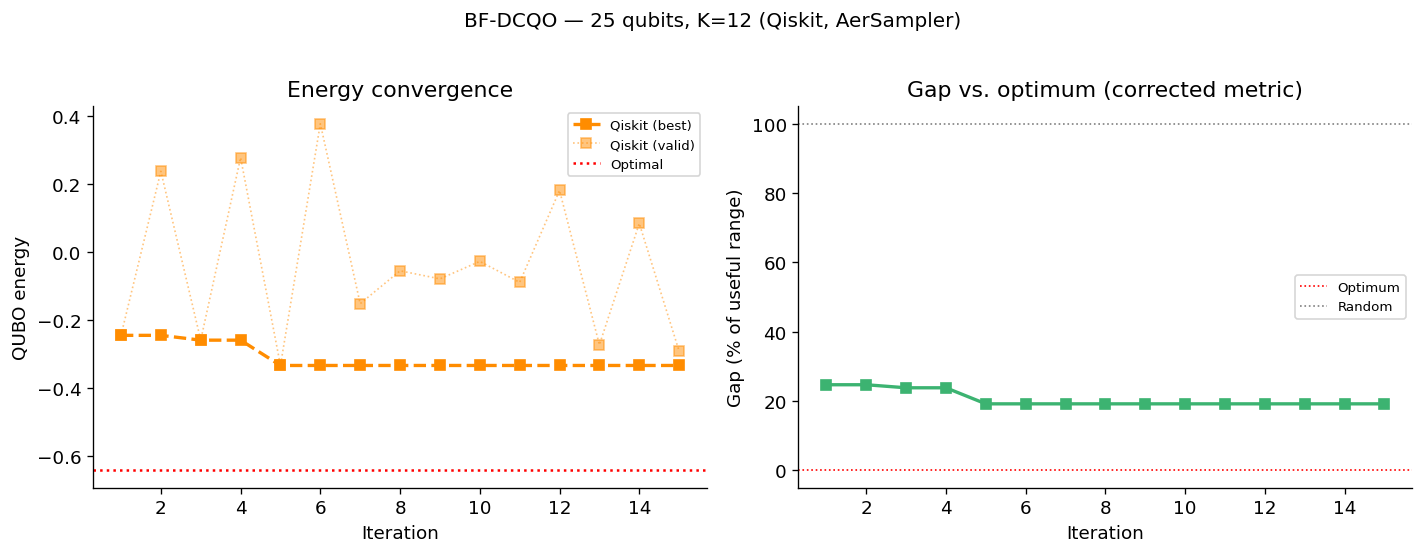


══════════════════════════════════════════════════
                                 Qiskit shots
──────────────────────────────────────────────────
BF optimal energy                     -0.6417
Random baseline                        0.9657
BF-DCQO energy                        -0.3334
Gap (% useful range)                    19.18
Valid solution                           True
Found exact optimum                     False
Time (s)                                663.3


In [10]:
iters = list(range(1, len(history_q) + 1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
be_q   = [h['best_energy'] for h in history_q]
bve_q  = [h['best_valid_e'] if h['best_valid_e'] else np.nan for h in history_q]
ax.plot(iters, be_q,   's--', color='darkorange', lw=2, label='Qiskit (best)')
ax.plot(iters, bve_q,  's:',  color='darkorange', lw=1, alpha=0.5, label='Qiskit (valid)')
ax.axhline(bf_e, color='red', ls=':', lw=1.5, label='Optimal')
ax.set_xlabel('Iteration'); ax.set_ylabel('QUBO energy')
ax.set_title('Energy convergence')
ax.legend(fontsize=8)

ax = axes[1]
gap_per_iter = [gap_pct(h['best_energy']) for h in history_q]
ax.plot(iters, gap_per_iter, 's-', color='mediumseagreen', lw=2)
ax.axhline(0, color='red', ls=':', lw=1, label='Optimum')
ax.axhline(100, color='gray', ls=':', lw=1, label='Random')
ax.set_xlabel('Iteration'); ax.set_ylabel('Gap (% of useful range)')
ax.set_title('Gap vs. optimum (corrected metric)')
ax.legend(fontsize=8)

plt.suptitle(f'BF-DCQO — {n} qubits, K={K} (Qiskit, AerSampler)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print('\n' + '═'*50)
print(f'{"":30} {"Qiskit shots":>14}')
print('─'*50)
rows = [
    ('BF optimal energy', f'{bf_e:.4f}'),
    ('Random baseline',     f'{E_RANDOM_MEAN:.4f}'),
    ('BF-DCQO energy', f'{best_e_q:.4f}'),
    ('Gap (% useful range)', f'{gap_q:.2f}'),
    ('Valid solution', str(is_valid(best_x_q,K))),
    ('Found exact optimum', str(np.allclose(best_x_q,bf_x))),
    ('Time (s)', f'{elapsed_q:.1f}'),
]
for label, v1 in rows:
    print(f'{label:<30} {v1:>14}')



A closer look at the per-iteration best valid energy reveals a pattern that 
resembles overshoot-undershoot oscillations, particularly in the early 
iterations. A plausible mechanism is that the bias-field update, driven by 
the top-nl samples rather than the full distribution, can overcorrect in 
one iteration, pushing the search toward a region that produces worse valid 
samples in the next. Whether this is an intrinsic property of the feedback 
mechanism at this scale and shot budget, or a parameter-dependent effect that 
could be mitigated (e.g. by adjusting nl or adding a damping factor to the 
bias update), remains an open question.

## 7. Effect of shot count

`n_shots` controls how many times we measure the circuit at each BF-DCQO
iteration before estimating $\langle\sigma_j^z\rangle$ and updating the
bias field. More shots reduce the statistical noise in the bias update, but
with diminishing returns — and on real hardware, shots cost time and money.
We sweep `n_shots` over {200, 500, 1000, 2000, 5000} with 10 seeds each
to separate the average effect from run-to-run variance.

In [11]:
# ── Effect of n_shots, n_l=10 fixed (matches [LS]), multiple seeds ──────
import json as _json
import os

SHOTS_CHECKPOINT_PATH = 'results_shots_n25.json'
shots_list  = [200, 500, 1000, 2000, 5000]
N_SEEDS_SHOTS = 10
NL_FIXED_SHOTS = 10   # matches [LS] ('we limit ourselves to n_l=10'), not swept

def load_shots_checkpoint():
    if os.path.exists(SHOTS_CHECKPOINT_PATH):
        with open(SHOTS_CHECKPOINT_PATH) as f:
            return _json.load(f)
    return {}

def save_shots_checkpoint(results):
    with open(SHOTS_CHECKPOINT_PATH, 'w') as f:
        _json.dump(results, f, indent=1)

print(f'Sweep: {len(shots_list)} shot counts x {N_SEEDS_SHOTS} seeds = '
      f'{len(shots_list)*N_SEEDS_SHOTS} runs, n_l={NL_FIXED_SHOTS} fixed, n={n}.')
print(f'Checkpoint file: {SHOTS_CHECKPOINT_PATH} (safe to re-run this cell to resume)')

results_shots_n25 = load_shots_checkpoint()

for n_shots_val in shots_list:
    key = str(n_shots_val)
    gaps_here = results_shots_n25.get(key, [])
    seeds_done = len(gaps_here)

    if seeds_done >= N_SEEDS_SHOTS:
        print(f'n_shots={n_shots_val:5d}: already complete ({seeds_done} seeds) -- skipping')
        continue

    print(f'n_shots={n_shots_val:5d}: {seeds_done}/{N_SEEDS_SHOTS} seeds done, running the rest...')
    for seed in range(seeds_done, N_SEEDS_SHOTS):
        t0 = time.time()
        _, be, hist, _ = bf_dcqo_qiskit(
            h_ising=h_ising, J_ising=J_ising,
            Q=Q, q=q, const=const, K=K, n=n,
            n_iterations=15, n_steps=N_STEPS, T=T_EVOL,
            n_shots=n_shots_val, nl=NL_FIXED_SHOTS, keep_fraction=KEEP_FRACTION,
            verbose=False, seed=seed
        )
        gap = gap_pct(be)
        gaps_here.append(gap)
        print(f'    seed={seed}: E={be:.4f}, gap={gap:.2f}%  ({time.time()-t0:.0f}s)')
        results_shots_n25[key] = gaps_here
        save_shots_checkpoint(results_shots_n25)

    print(f'    --> n_shots={n_shots_val}: mean gap={np.mean(gaps_here):.2f}% '
          f'(+/-{np.std(gaps_here):.2f})')

print('\n' + '='*70)
print('SUMMARY: effect of n_shots')
print('='*70)
for n_shots_val in shots_list:
    gaps_here = results_shots_n25[str(n_shots_val)]
    print(f'  n_shots={n_shots_val:5d}: mean gap={np.mean(gaps_here):6.2f}% '
          f'(+/-{np.std(gaps_here):.2f})  [{[f"{g:.1f}%" for g in gaps_here]}]')

Sweep: 5 shot counts x 10 seeds = 50 runs, n_l=10 fixed, n=25.
Checkpoint file: results_shots_n25.json (safe to re-run this cell to resume)
n_shots=  200: already complete (10 seeds) -- skipping
n_shots=  500: already complete (10 seeds) -- skipping
n_shots= 1000: already complete (10 seeds) -- skipping
n_shots= 2000: already complete (10 seeds) -- skipping
n_shots= 5000: already complete (10 seeds) -- skipping

SUMMARY: effect of n_shots
  n_shots=  200: mean gap= 25.79% (+/-5.79)  [['28.4%', '27.9%', '30.5%', '17.7%', '32.3%', '14.8%', '25.3%', '24.3%', '33.8%', '23.0%']]
  n_shots=  500: mean gap= 24.23% (+/-5.70)  [['27.9%', '29.4%', '21.5%', '17.7%', '19.6%', '24.7%', '15.3%', '35.0%', '28.3%', '23.0%']]
  n_shots= 1000: mean gap= 18.70% (+/-4.90)  [['21.3%', '25.0%', '21.5%', '17.7%', '17.3%', '24.7%', '12.4%', '22.3%', '9.7%', '15.0%']]
  n_shots= 2000: mean gap= 17.28% (+/-3.61)  [['9.0%', '18.4%', '16.3%', '17.7%', '20.6%', '21.1%', '15.3%', '22.5%', '15.8%', '16.1%']]
  n_sho

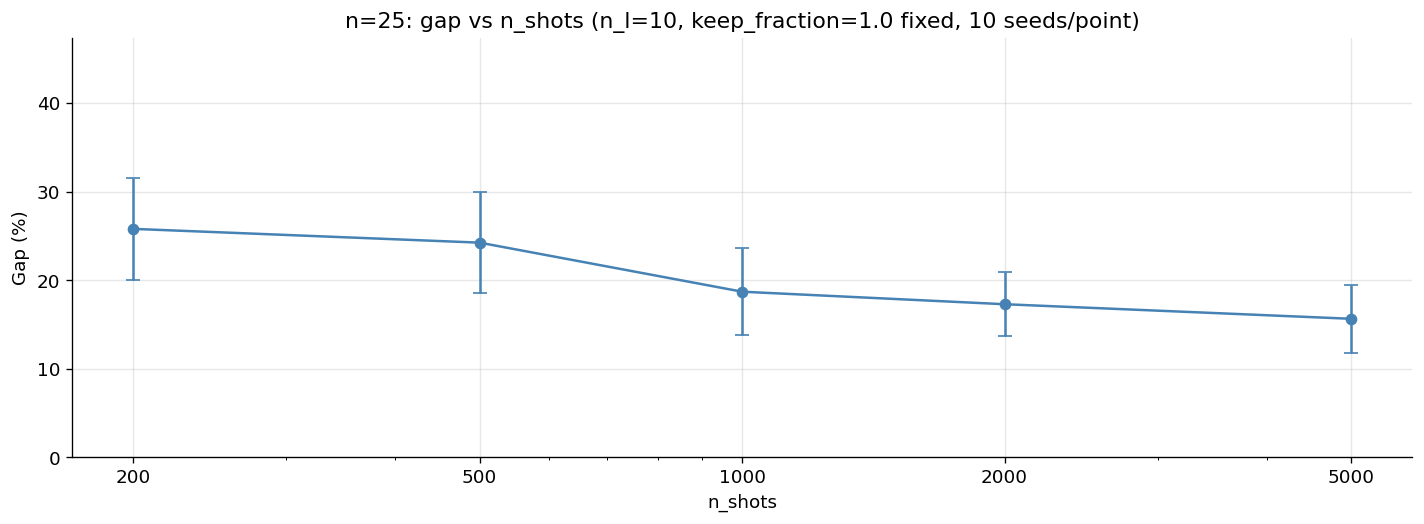

In [12]:
# ── Chart: gap vs. n_shots (mean ± std, with exact-optimum hit rate) ───────
mean_gaps = [np.mean(results_shots_n25[str(s)]) for s in shots_list]
std_gaps  = [np.std( results_shots_n25[str(s)]) for s in shots_list]
frac_opts = [np.mean([g == 0.0 for g in results_shots_n25[str(s)]]) for s in shots_list]

fig, axes = plt.subplots(1, 1, figsize=(12, 4.5))
ax=axes
ax.errorbar(shots_list, mean_gaps, yerr=std_gaps, marker='o', capsize=4, color='steelblue')
ax.set_xlabel('n_shots'); ax.set_ylabel('Gap (%)')
ax.set_title(f'n={n}: gap vs n_shots (n_l={NL_FIXED_SHOTS}, keep_fraction={KEEP_FRACTION} fixed, '
             f'{N_SEEDS_SHOTS} seeds/point)')
ax.set_xscale('log')
ax.set_xticks(shots_list)
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.set_ylim(0, 1.5 * max(m + s for m, s in zip(mean_gaps, std_gaps)))
ax.grid(alpha=0.3)


plt.tight_layout()
plt.show()

Shot count has a clear and meaningful effect on solution quality: mean gap 
decreases monotonically from ~26% at 200 shots to ~16% at 5000, with the 
largest improvement between 500 and 1000 shots. The run-to-run variance also 
decreases with shot count (std from ±5.8 at 200 shots to ±3.6–3.8 at 
2000–5000), consistent with a more stable bias-field estimate.

This is consistent with the role of n_shots in BF-DCQO: more measurements 
reduce the statistical noise in the ⟨σ_z⟩ estimates used to update the bias 
field.

*Note: based on N=10 seeds; mean trends are reliable but std estimates 
carry uncertainty. Conclusions are drawn from the qualitative pattern.*

## 8. Trotter step dependence

$N_{\text{steps}}$ trades off two effects in opposite directions: more
steps reduce Trotter digitization error (closer to the true continuous CD
evolution), but also increase total gate count. 

In [13]:
# ── Effect of N_steps, no pruning level, multi-seed ─────────
import json as _json
import os

TROTTER_CHECKPOINT_PATH = 'results_trotter.json'
NSTEPS_GRID = [2, 4, 6, 8]
N_SEEDS_TROTTER = 5
NL_FIXED_TROTTER     = 10 #  matches [LS], from Section 9
CUTOFF_FIXED_TROTTER = 0
CUTOFF_LABEL_TROTTER = "no_pruning_pure_trotter"

def load_trotter_checkpoint():
    if os.path.exists(TROTTER_CHECKPOINT_PATH):
        with open(TROTTER_CHECKPOINT_PATH) as f:
            return _json.load(f)
    return {}

def save_trotter_checkpoint(results):
    with open(TROTTER_CHECKPOINT_PATH, 'w') as f:
        _json.dump(results, f, indent=1)

print(f'Sweep: {len(NSTEPS_GRID)} N_steps values x {N_SEEDS_TROTTER} seeds = '
      f'{len(NSTEPS_GRID)*N_SEEDS_TROTTER} runs. pruning={CUTOFF_LABEL_TROTTER} '
      f'(theta_cutoff={CUTOFF_FIXED_TROTTER:.3e}), n_l={NL_FIXED_TROTTER} fixed.')
print(f'Checkpoint file: {TROTTER_CHECKPOINT_PATH} (safe to re-run this cell to resume)')

results_trotter = load_trotter_checkpoint()

for n_steps_val in NSTEPS_GRID:
    key = str(n_steps_val)
    gaps_here = results_trotter.get(key, [])
    seeds_done = len(gaps_here)

    if seeds_done >= N_SEEDS_TROTTER:
        print(f'N_steps={n_steps_val}: already complete ({seeds_done} seeds) -- skipping')
        continue

    print(f'N_steps={n_steps_val}: {seeds_done}/{N_SEEDS_TROTTER} seeds done, running the rest...')
    for seed in range(seeds_done, N_SEEDS_TROTTER):
        t0 = time.time()
        _, be, hist, _ = bf_dcqo_qiskit(
            h_ising=h_ising, J_ising=J_ising,
            Q=Q, q=q, const=const, K=K, n=n,
            n_iterations=15, n_steps=n_steps_val, T=T_EVOL,
            n_shots=5000, nl=NL_FIXED_TROTTER, theta_cutoff=CUTOFF_FIXED_TROTTER,
            verbose=False, seed=seed
        )
        gap = gap_pct(be)
        gaps_here.append(gap)
        print(f'    seed={seed}: E={be:.4f}, gap={gap:.2f}%  '
              f'(gates={hist[0]["n_gates"]}, {time.time()-t0:.0f}s)')
        results_trotter[key] = gaps_here
        save_trotter_checkpoint(results_trotter)

    print(f'    --> N_steps={n_steps_val}: mean gap={np.mean(gaps_here):.2f}% '
          f'(+/-{np.std(gaps_here):.2f})')

print('\n' + '='*60)
print(f'SUMMARY: effect of N_steps ({CUTOFF_LABEL_TROTTER} pruning, n_l={NL_FIXED_TROTTER} fixed)')
print('='*60)
for n_steps_val in NSTEPS_GRID:
    gaps_here = results_trotter[str(n_steps_val)]
    print(f'  N_steps={n_steps_val}: mean gap={np.mean(gaps_here):6.2f}% '
          f'(+/-{np.std(gaps_here):.2f})  [{[f"{g:.1f}%" for g in gaps_here]}]')

Sweep: 4 N_steps values x 5 seeds = 20 runs. pruning=no_pruning_pure_trotter (theta_cutoff=0.000e+00), n_l=10 fixed.
Checkpoint file: results_trotter.json (safe to re-run this cell to resume)
N_steps=2: already complete (5 seeds) -- skipping
N_steps=4: already complete (5 seeds) -- skipping
N_steps=6: already complete (5 seeds) -- skipping
N_steps=8: already complete (5 seeds) -- skipping

SUMMARY: effect of N_steps (no_pruning_pure_trotter pruning, n_l=10 fixed)
  N_steps=2: mean gap= 14.66% (+/-3.62)  [['17.7%', '12.6%', '19.5%', '9.3%', '14.3%']]
  N_steps=4: mean gap= 15.71% (+/-4.72)  [['12.3%', '18.7%', '19.7%', '8.1%', '19.8%']]
  N_steps=6: mean gap= 12.64% (+/-4.04)  [['16.5%', '15.0%', '4.9%', '13.8%', '13.0%']]
  N_steps=8: mean gap= 14.77% (+/-4.15)  [['12.9%', '15.6%', '22.3%', '10.2%', '12.9%']]


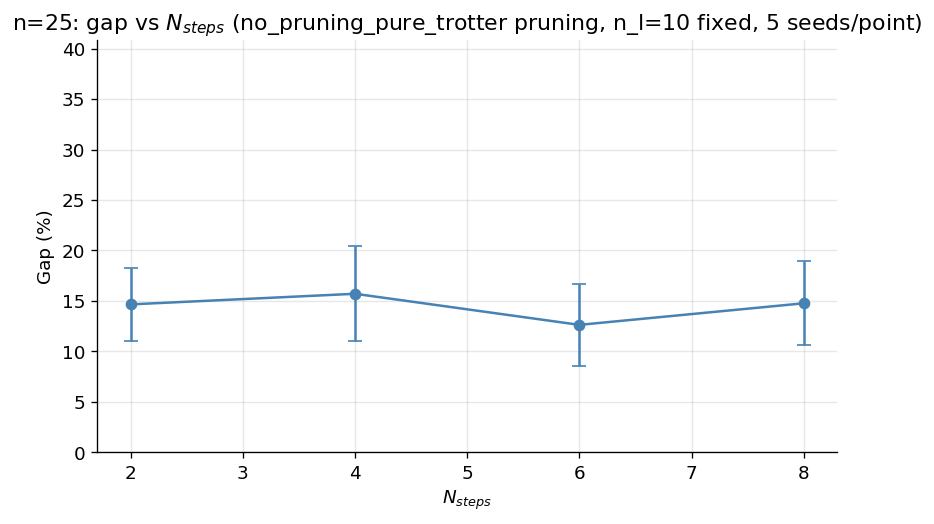

In [14]:
# ── Chart: gap vs N_steps ───────────────────────────────────────────────────
mean_gaps_ns = [np.mean(results_trotter[str(ns)]) for ns in NSTEPS_GRID]
std_gaps_ns  = [np.std( results_trotter[str(ns)]) for ns in NSTEPS_GRID]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar(NSTEPS_GRID, mean_gaps_ns, yerr=std_gaps_ns, marker='o', capsize=4, color='steelblue')
ax.set_xlabel('$N_{steps}$'); ax.set_ylabel('Gap (%)')
ax.set_title(f'n={n}: gap vs $N_{{steps}}$ ({CUTOFF_LABEL_TROTTER} pruning, '
             f'n_l={NL_FIXED_TROTTER} fixed, {N_SEEDS_TROTTER} seeds/point)')
ax.set_ylim(0, 2 * max(m + s for m, s in zip(mean_gaps_ns, std_gaps_ns)))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Results
The sweep shows no consistent monotonic trend with N_steps: mean gaps range from 12.6% (N_steps=6) to 15.7% (N_steps=4), with standard deviations of 3–5 points that overlap across all configurations. No value of N_steps dominates the others in a statistically meaningful way.
This is consistent with the impulse regime approximation used in the paper: 
the CD term captures most of the correction within a handful of Trotter steps, 
so beyond N_steps=2–4 additional steps add circuit depth without improving 
solution quality. On real hardware, where deeper circuits accumulate more 
decoherence, the optimal N_steps may be even lower than what noiseless 
simulation suggests.

*Note: based on N=10 seeds; mean trends are reliable but std estimates 
carry uncertainty. Conclusions are drawn from the qualitative pattern.*

## 9. Effect of pruning


**Pruning**: absolute `theta_cutoff` (Algorithm 2 of [LS]), calibrated in Section 6 to
  reproduce the gate-removal fractions [LS] reports (medium ~40%, high ~60%) -- since [LS] never publishes the numeric
  cutoff itself, only the resulting removal fraction.

In [15]:
import json as _json
import os

CHECKPOINT_PATH = 'results_pruning.json'

# ── Grid definition: absolute theta_cutoff (matches [LS] Algorithm 2), n_l fixed at 10 ──
# CALIBRATED_CUTOFFS comes from the calibration cell in Section 6 ("Circuit inspection"),
# which maps each label to a theta_cutoff value reproducing that target gate-removal fraction
# on THIS problem instance.
CUTOFF_GRID = list(CALIBRATED_CUTOFFS.items())   # [(label, theta_cutoff), ...]
NL_FIXED = 10     # matches [LS] exactly -- not swept, see Section 9 intro
N_SEEDS  = 10

N_ITERATIONS_FIXED = 10
N_SHOTS_FIXED = 5000


def load_checkpoint():
    if os.path.exists(CHECKPOINT_PATH):
        with open(CHECKPOINT_PATH) as f:
            return _json.load(f)
    return {}


def save_checkpoint(results):
    with open(CHECKPOINT_PATH, 'w') as f:
        _json.dump(results, f, indent=1)


def grid_key(label):
    return f'cutoff={label}'


print(f'Grid: {len(CUTOFF_GRID)} pruning levels x {N_SEEDS} seeds '
      f'= {len(CUTOFF_GRID)*N_SEEDS} runs (n_l={NL_FIXED} fixed, matching [LS]),')
print(f'Checkpoint file: {CHECKPOINT_PATH} (delete it before re-running if the problem/n/K changed!)')

Grid: 3 pruning levels x 10 seeds = 30 runs (n_l=10 fixed, matching [LS]),
Checkpoint file: results_pruning.json (delete it before re-running if the problem/n/K changed!)


In [16]:
# ── Grid scan with checkpointing (safe to interrupt and resume) ────────────
results_grid = load_checkpoint()
total_points = len(CUTOFF_GRID)
done_points  = 0

for label, cutoff in CUTOFF_GRID:
    done_points += 1
    key = grid_key(label)

    if key in results_grid and len(results_grid[key]) >= N_SEEDS:
        print(f'[{done_points}/{total_points}] {key}: already complete '
              f'({len(results_grid[key])} seeds) -- skipping')
        continue

    gaps_here = results_grid.get(key, [])
    seeds_done = len(gaps_here)
    print(f'[{done_points}/{total_points}] {key} (theta_cutoff={cutoff:.3e}): '
          f'{seeds_done}/{N_SEEDS} seeds done, running the rest...')

    for seed in range(seeds_done, N_SEEDS):
        t0 = time.time()
        _, be, hist, _ = bf_dcqo_qiskit(
            h_ising=h_ising, J_ising=J_ising,
            Q=Q, q=q, const=const, K=K, n=n,
            n_iterations=N_ITERATIONS_FIXED, n_steps=N_STEPS, T=T_EVOL,
            n_shots=N_SHOTS_FIXED, nl=NL_FIXED, theta_cutoff=cutoff,
            verbose=False, seed=seed
        )
        gap = gap_pct(be)
        gaps_here.append(gap)
        print(f'    seed={seed}: E={be:.4f}, gap={gap:.2f}%  ({time.time()-t0:.0f}s)')

        results_grid[key] = gaps_here
        save_checkpoint(results_grid)

    print(f'    --> {key}: mean gap={np.mean(gaps_here):.2f}% (+/-{np.std(gaps_here):.2f})')

print('\nGrid scan complete (or already was, from a previous checkpoint).')

[1/3] cutoff=none: already complete (10 seeds) -- skipping
[2/3] cutoff=medium (~[LS] 36-qubit): already complete (10 seeds) -- skipping
[3/3] cutoff=high (~[LS] 36-qubit): already complete (10 seeds) -- skipping

Grid scan complete (or already was, from a previous checkpoint).


In [17]:
# ── Aggregate into a DataFrame for plotting / inspection ───────────────────
results_grid = load_checkpoint()
label_to_cutoff = dict(CUTOFF_GRID)
rows = []
for key, gaps_here in results_grid.items():
    if key.startswith('FINAL_'):
        continue
    if not key.startswith('cutoff='):
        continue   # ignore any stale keys from the old kf=.._nl=.. grid format
    label = key[len('cutoff='):]
    if label not in label_to_cutoff or len(gaps_here) == 0:
        continue
    rows.append({
        'label': label, 'theta_cutoff': label_to_cutoff[label],
        'mean_gap': np.mean(gaps_here), 'std_gap': np.std(gaps_here),
        'n_seeds': len(gaps_here), 'gaps': gaps_here
    })
df_grid = pd.DataFrame(rows)
print(f'{len(df_grid)} grid points found in the checkpoint file.')
print(df_grid[['label', 'theta_cutoff', 'mean_gap', 'std_gap', 'n_seeds']]
      .sort_values('mean_gap').to_string(index=False))

best_row = df_grid.loc[df_grid['mean_gap'].idxmin()]
print(f"\nBest pruning level: {best_row['label']} (theta_cutoff={best_row['theta_cutoff']:.3e}), "
      f"mean gap={best_row['mean_gap']:.2f}% (+/-{best_row['std_gap']:.2f}, {best_row['n_seeds']} seeds)")

3 grid points found in the checkpoint file.
                  label  theta_cutoff  mean_gap  std_gap  n_seeds
medium (~[LS] 36-qubit)      0.000031 15.583635 3.573001       10
                   none      0.000000 15.636749 3.804832       10
  high (~[LS] 36-qubit)      0.000350 17.367719 6.202148       10

Best pruning level: medium (~[LS] 36-qubit) (theta_cutoff=3.058e-05), mean gap=15.58% (+/-3.57, 10 seeds)


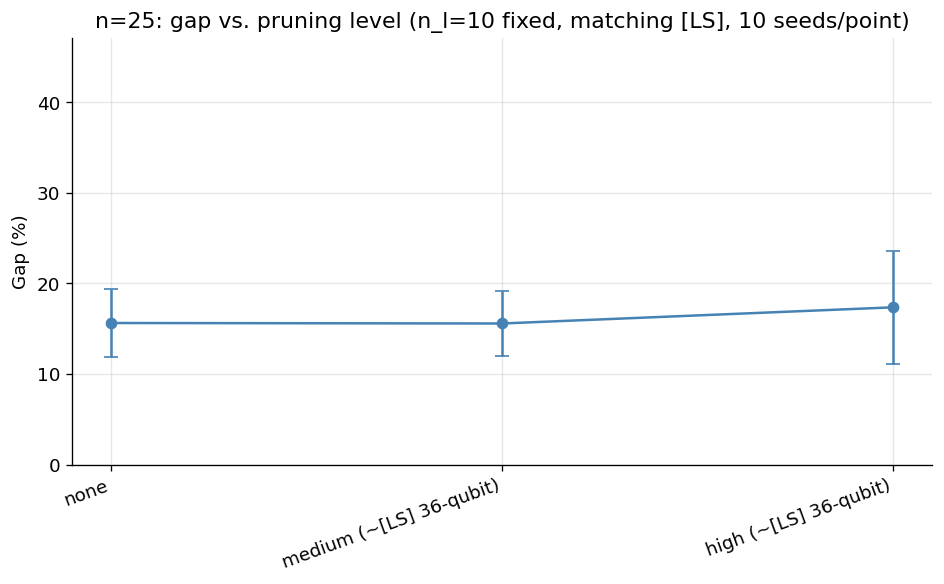

In [18]:
# ── Error-bar chart: gap vs. pruning level (theta_cutoff, matching [LS] removal fractions) ──
df_plot = df_grid.sort_values('theta_cutoff')

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(range(len(df_plot)), df_plot['mean_gap'], yerr=df_plot['std_gap'],
            marker='o', capsize=4, color='steelblue')
ax.set_xticks(range(len(df_plot)))
ax.set_xticklabels(df_plot['label'], rotation=20, ha='right')
ax.set_ylabel('Gap (%)')
ax.set_title(f'n={n}: gap vs. pruning level (n_l={NL_FIXED} fixed, matching [LS], '
             f'{int(df_plot["n_seeds"].iloc[0])} seeds/point)')
ax.set_ylim(0, 2 * (df_plot['mean_gap'] + df_plot['std_gap']).max())
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Results (10 seeds)

| Pruning level | mean gap | std | n_seeds |
|---|---|---|---|
| none | 15.64% | ±3.80 | 10 |
| medium (~40% gate removal) | 15.58% | ±3.57 | 10 |
| high (~60% gate removal) | 17.37% | ±6.20 | 10 |

None and medium are statistically indistinguishable — a difference of 0.06 points 
with fully overlapping standard deviations. High shows higher variance (±6.20 vs 
±3.6–3.8) and a slightly worse mean, but also produces the best individual result 
across all seeds and pruning levels (seed=8: gap=5.27%).

**Limitation:** with N=10 seeds per pruning level, the sample is too small to 
determine whether high pruning's higher variance reflects a structural property 
of the algorithm (more aggressive gate removal changes the optimization landscape, 
occasionally finding better solutions but less reliably) or is simply sampling 
noise. Resolving this would require more seeds — computationally prohibitive 
on a classical simulator. 

**Main finding:** up to ~40% gate removal (medium), pruning has no statistically 
meaningful effect on this instance on solution quality in noiseless simulation, consistent with 
the theoretical expectation that pruning benefits emerge primarily under hardware 
noise, where each additional gate carries a decoherence cost.

## Section 9a: Effect of pruning under a realistic noise model

The ideal-simulation results showed pruning to be statistically
neutral at n=25: removing counterdiabatic terms with small |θ| did not
measurably change solution quality, probably because there was no gate-count-induced
decoherence to mitigate in a noiseless simulator.

Cadavid et al. predict that this picture changes under real hardware noise:
extra gates from negligible-|θ| terms cost decoherence without contributing
meaningful signal, so pruning should recover an advantage once circuit-level
noise is present.

**Setup.** We test this on a reduced sub-problem (`N_SUB=14` assets, sliced
from the same `mu`/`C` used for the full n=25 problem, same cardinality
fraction `K_SUB`), under a depolarizing noise model calibrated on IonQ Forte
reported fidelities (single-qubit 99.98%, two-qubit 99.3%), simulated exactly
via Aer's `density_matrix` method (no measurements/resets mid-circuit, so this
is exact, not a stochastic per-shot approximation).

Two pruning levels are compared via `keep_fraction` (percentile-based, so it
requires no recalibration across problem sizes, unlike an absolute
`theta_cutoff`):
- `none` (`keep_fraction=1.0`): no pruning, 1456 CX gates.
- `high` (`keep_fraction=0.40`): keep top 40% of |θ| terms, 632 CX gates
  (-56.6%).

5 seeds per configuration, 8 BF-DCQO iterations, 1000 shots/iteration. Two
metrics are tracked: the usual cumulative `gap` (best energy found vs.
brute-force optimum) and `frac_valid_raw` (fraction of valid, cardinality-K
samples in the final iterations).

In [19]:
def bf_dcqo_qiskit_noisy(
    h_ising: np.ndarray,
    J_ising: np.ndarray,
    Q: np.ndarray,
    q: np.ndarray,
    const: float,
    K: int,
    n: int,
    n_iterations: int = 10,
    n_steps: int = 4,
    T: float = 0.1,
    n_shots: int = 500,
    nl: int = 10,
    keep_fraction: float = 1.0,
    theta_cutoff: float = None,
    verbose: bool = True,
    seed: int = None,
    noise_model=None,
    sampler_method: str = 'automatic',
) -> tuple:
    """
    Sibling of bf_dcqo_qiskit, supporting an external noise_model.
    Logic identical to the original; the only difference is the
    construction of the sampler (backend_options/noise_model).
    noise_model=None reproduces exactly the ideal-simulation behavior.
    """
    best_x, best_e, history, circuits = None, np.inf, [], []
    current_h_bias = np.zeros(n)

    backend_options = {}
    if noise_model is not None:
        backend_options['noise_model'] = noise_model
        backend_options['method'] = sampler_method

    for r in range(1, n_iterations + 1):
        run_options = {'seed_simulator': seed + r} if seed is not None else {}
        sampler = AerSampler(
            backend_options=backend_options or None,
            run_options=run_options or None,
        )

        qc = build_dcqo_circuit(
            n, h_ising, J_ising, current_h_bias,
            n_steps=n_steps, T=T, keep_fraction=keep_fraction, theta_cutoff=theta_cutoff
        )
        circuits.append(qc)

        job    = sampler.run(qc, shots=n_shots)
        result = job.result()
        try:
            counts = result.get_counts()
        except AttributeError:
            counts = dict(result.quasi_dists[0].binary_probabilities())
            counts = {k: max(1, round(v * n_shots)) for k, v in counts.items() if v > 0}

        samples = counts_to_bitstrings(counts, n)
        frac_valid_raw = sum(c for x, c in samples if is_valid(x, K)) / n_shots
        scored_unique = [(qubo_energy(x, Q, q, const), x, c) for x, c in samples]
        scored_unique.sort(key=lambda t: t[0])

        top_nl, remaining = [], nl
        for e, x, c in scored_unique:
            if remaining <= 0:
                break
            take = min(c, remaining)
            top_nl.append((e, x, take))
            remaining -= take

        spin_avg = np.zeros(n)
        for _, x, w in top_nl:
            spin_avg += w * (1 - 2*x)
        spin_avg /= nl
        current_h_bias = +spin_avg

        for e, x, w in top_nl:
            if e < best_e:
                best_e = e
                best_x = x.copy()

        valid_top  = [(e, x, w) for e, x, w in top_nl if is_valid(x, K)]
        best_valid = valid_top[0][0] if valid_top else None
        n_valid_weighted = sum(w for _, _, w in valid_top)
        n_gates    = sum(qc.count_ops().values())

        history.append({
            'iter': r, 'best_energy': best_e, 'best_valid_e': best_valid,
            'n_valid': n_valid_weighted, 'frac_valid_raw': frac_valid_raw,
            'bias_fields': current_h_bias.copy(), 'n_gates': n_gates,
        })

        if verbose:
            bve = f'{best_valid:.4f}' if best_valid is not None else 'none'
            print(f'  Iter {r:2d} | best E: {best_e:.4f} | '
                  f'valid in top-{nl}: {n_valid_weighted:2d} | '
                  f'best valid: {bve} | gates: {n_gates} | '
                  f'raw valid: {frac_valid_raw*100:5.1f}%')

    return best_x, best_e, history, circuits


print('bf_dcqo_qiskit_noisy defined (sibling of bf_dcqo_qiskit, supports noise_model).')

bf_dcqo_qiskit_noisy defined (sibling of bf_dcqo_qiskit, supports noise_model).


In [20]:
# ── Section 9a setup: sub-problem + noise model + experiment grid ──
from qiskit_aer.noise import NoiseModel, depolarizing_error

# Fidelities from [LS] (IonQ Forte): single-qubit ~99.98%, two-qubit ~99.3%
ERROR_1Q = 1 - 0.9998
ERROR_2Q = 1 - 0.993

def build_noise_model(gate_names_1q=('rx', 'ry', 'rz'), gate_names_2q=('cx',)):
    nm = NoiseModel()
    err_1q = depolarizing_error(ERROR_1Q, 1)
    err_2q = depolarizing_error(ERROR_2Q, 2)
    nm.add_all_qubit_quantum_error(err_1q, list(gate_names_1q))
    nm.add_all_qubit_quantum_error(err_2q, list(gate_names_2q))
    return nm

noise_model = build_noise_model()

# Sub-problem: same build_qubo / build_ising_coeffs pipeline as the main n=25
# problem, applied to the first N_SUB assets only (sliced mu/C/tickers).
N_SUB = 14
K_SUB = max(1, round(K * N_SUB / n))

tickers_sub = tickers[:N_SUB]
mu_sub      = mu[:N_SUB]
C_sub       = C[:N_SUB, :N_SUB]

Q_sub, q_sub, const_sub, Lambda_sub = build_qubo(mu_sub, C_sub, K_SUB, gamma, verbose=True)
h_ising_sub, J_ising_sub = build_ising_coeffs(Q_sub, q_sub, N_SUB)

bf_e_sub = np.inf
bf_x_sub = None
for combo in combinations(range(N_SUB), K_SUB):
    x = np.zeros(N_SUB); x[list(combo)] = 1
    e = qubo_energy(x, Q_sub, q_sub, const_sub)
    if e < bf_e_sub:
        bf_e_sub = e; bf_x_sub = x.copy()
print(f'Sub-problem optimal: E={bf_e_sub:.4f}  '
      f'(states={2**N_SUB}, valid portfolios={comb(N_SUB, K_SUB)})')

np.random.seed(123)
random_energies_sub = []
for _ in range(2000):
    combo = np.random.choice(N_SUB, K_SUB, replace=False)
    x = np.zeros(N_SUB); x[combo] = 1
    random_energies_sub.append(qubo_energy(x, Q_sub, q_sub, const_sub))
E_RANDOM_MEAN_SUB = np.mean(random_energies_sub)
SCALE_RANGE_SUB = E_RANDOM_MEAN_SUB - bf_e_sub

def gap_pct_sub(e):
    return abs(e - bf_e_sub) / SCALE_RANGE_SUB * 100

# Noisy run parameters
N_SHOTS_NOISY      = 1000
N_ITERATIONS_NOISY = 8
N_SEEDS_NOISY       = 5
TAIL_WINDOW         = 3

NOISY_CUTOFF_GRID = [('none', 1.0), ('high', 0.40)]   # keep_fraction: 1.0=no pruning, 0.40=keep top 40% (~60% removed)

print(f'N_SUB={N_SUB}, K_SUB={K_SUB}, Lambda_sub={Lambda_sub:.4f}')

  Λ=53.6966
Sub-problem optimal: E=-0.6571  (states=16384, valid portfolios=3432)
N_SUB=14, K_SUB=7, Lambda_sub=53.6966


In [21]:
# ── Sanity check: keep_fraction=0.40 actually removes a meaningful share of gates? ──
qc_none_sub = build_dcqo_circuit(N_SUB, h_ising_sub, J_ising_sub, np.zeros(N_SUB),
                                  n_steps=N_STEPS, T=T_EVOL, keep_fraction=1.0)
qc_high_sub = build_dcqo_circuit(N_SUB, h_ising_sub, J_ising_sub, np.zeros(N_SUB),
                                  n_steps=N_STEPS, T=T_EVOL, keep_fraction=0.40)
print('none:', dict(qc_none_sub.count_ops()))
print('high:', dict(qc_high_sub.count_ops()))

none: {'rx': 1456, 'cx': 1456, 'rz': 728, 'ry': 70, 'measure': 14}
high: {'rx': 632, 'cx': 632, 'rz': 316, 'ry': 14, 'measure': 14}


In [22]:
NOISY_CHECKPOINT_PATH = f'results_noisy_n{N_SUB}.json'

def load_noisy_checkpoint():
    if os.path.exists(NOISY_CHECKPOINT_PATH):
        with open(NOISY_CHECKPOINT_PATH) as f:
            return _json.load(f)
    return {}

def save_noisy_checkpoint(results):
    with open(NOISY_CHECKPOINT_PATH, 'w') as f:
        _json.dump(results, f, indent=1)

def history_to_jsonable(hist):
    # 'bias_fields' is a numpy array per iteration -- not JSON-serializable as-is
    out = []
    for h in hist:
        h2 = dict(h)
        h2['bias_fields'] = h2['bias_fields'].tolist()
        out.append(h2)
    return out

results_noisy = load_noisy_checkpoint()

for label, cutoff in NOISY_CUTOFF_GRID:
    entry = results_noisy.get(label, {'gaps': [], 'frac_valid_tail': [], 'history': []})
    seeds_done = len(entry['gaps'])

    if seeds_done >= N_SEEDS_NOISY:
        print(f'pruning={label}: already complete ({seeds_done} seeds) -- skipping')
        results_noisy[label] = entry
        continue

    print(f'--- pruning={label} (theta_cutoff={cutoff}): '
          f'{seeds_done}/{N_SEEDS_NOISY} seeds done, running the rest... ---')

    for seed in range(seeds_done, N_SEEDS_NOISY):
        t0 = time.time()
        _, be, hist, _ = bf_dcqo_qiskit_noisy(
            h_ising=h_ising_sub, J_ising=J_ising_sub, Q=Q_sub, q=q_sub,
            const=const_sub, K=K_SUB, n=N_SUB,
            n_iterations=N_ITERATIONS_NOISY, n_steps=N_STEPS, T=T_EVOL,
            n_shots=N_SHOTS_NOISY, nl=10, keep_fraction=cutoff, 
            verbose=False, seed=seed,
            noise_model=noise_model, sampler_method='density_matrix',
        )
        gap = gap_pct_sub(be)
        frac_valid_tail = float(np.mean([h['frac_valid_raw'] for h in hist[-TAIL_WINDOW:]]))

        entry['gaps'].append(gap)
        entry['frac_valid_tail'].append(frac_valid_tail)
        entry['history'].append(history_to_jsonable(hist))   # <-- full per-iteration record
        results_noisy[label] = entry
        save_noisy_checkpoint(results_noisy)

        print(f'  seed={seed}: E={be:.4f}, gap={gap:.2f}%, '
              f'frac_valid(tail)={frac_valid_tail:.3f}  ({time.time()-t0:.0f}s)')

    print(f'  --> mean gap={np.mean(entry["gaps"]):.2f}% (+/-{np.std(entry["gaps"]):.2f}), '
          f'mean frac_valid(tail)={np.mean(entry["frac_valid_tail"]):.3f} '
          f'(+/-{np.std(entry["frac_valid_tail"]):.3f})\n')

print(f'SUMMARY (noisy, IonQ Forte-calibrated, N_SUB={N_SUB}):')
for label, entry in results_noisy.items():
    print(f'  {label}: mean gap={np.mean(entry["gaps"]):.2f}% '
          f'(+/-{np.std(entry["gaps"]):.2f}), '
          f'mean frac_valid(tail)={np.mean(entry["frac_valid_tail"]):.3f} '
          f'(+/-{np.std(entry["frac_valid_tail"]):.3f})')

pruning=none: already complete (5 seeds) -- skipping
pruning=high: already complete (5 seeds) -- skipping
SUMMARY (noisy, IonQ Forte-calibrated, N_SUB=14):
  none: mean gap=7.05% (+/-5.53), mean frac_valid(tail)=0.231 (+/-0.006)
  high: mean gap=7.91% (+/-8.57), mean frac_valid(tail)=0.253 (+/-0.006)


### Results

| Metric | none (keep_fraction=1.0) | high (keep_fraction=0.40) |
|---|---|---|
| mean gap | 7.05% (±5.53) | 7.91% (±8.57) |
| mean frac_valid (tail) | 0.231 (±0.006) | 0.253 (±0.006) |

Random-uniform baseline for this sub-problem: `C(14,7)/2^14 = 20.95%`.

**`gap` is not discriminating at this shot budget** — the standard deviations 
exceed the difference between means. With 8000 total shots over 2^14 states, 
even a degraded distribution has a non-trivial chance of hitting the optimum 
at least once.

**`frac_valid_raw` shows a small but consistent effect**: both configurations 
sit above the random baseline, and `high` is above `none` on every one of the 
5 seeds (+2.2pp vs +4.4pp over random). The direction seems consistent with 
Cadavid et al.'s prediction that pruning recovers an advantage under circuit 
noise that is absent in ideal simulation.

**Caveats**: single sub-problem, single keep_fraction value, gate-level 
depolarizing noise only, 5 seeds. The effect direction is encouraging but 
this configuration alone does not establish generality.

## Section 10: From local simulation to IonQ's cloud platform

Sections 6–9 ran entirely on `AerSampler`, locally. This section moves
execution to **IonQ's cloud simulator** (`ionq_simulator`), via the
`qiskit-ionq` provider, as a step toward validating BF-DCQO closer to real
trapped-ion hardware. The algorithm itself doesn't change; everything
downstream (post-selection, bias update, scoring) is backend-agnostic by
construction.

This section runs on the same `N_SUB=14` sub-problem and noise model setup
as Section 9a, to allow a direct comparison between Aer's depolarizing
model and IonQ's own `aria-1` cloud noise model.

In [23]:
import os
os.environ["IONQ_API_TOKEN"] = "XXX"

In [24]:
# ── BF-DCQO on IonQ cloud simulator (aria-1 noise model), sub-problem N_SUB=14 ──
import json as _json
import os
from qiskit_ionq import IonQProvider
from qiskit import transpile

provider = IonQProvider(os.environ["IONQ_API_TOKEN"])
ionq_backend = provider.get_backend("ionq_simulator")
ionq_backend.set_options(noise_model="aria-1")


# Sanity-check circuit (same sub-problem as Section 9a, N_SUB=14)
qc_small = build_dcqo_circuit(
    n=N_SUB,
    h_ising=h_ising_sub,
    J_ising=J_ising_sub,
    h_bias=np.zeros(N_SUB),
    n_steps=N_STEPS,
    T=T_EVOL
)
print(f'Test circuit: {dict(qc_small.count_ops())}, depth={qc_small.depth()}')

IONQ_SUB_CHECKPOINT = f'results_noisy_ionq_n{N_SUB}.json'

# Matched to Aer (Section 9a) for a direct, apples-to-apples comparison
N_ITERATIONS_IONQ = 8
N_SEEDS_IONQ      = 5
N_SHOTS_IONQ      = 1000
TAIL_WINDOW_IONQ  = 3


def load_ionq_checkpoint():
    if os.path.exists(IONQ_SUB_CHECKPOINT):
        with open(IONQ_SUB_CHECKPOINT) as f:
            return _json.load(f)
    return {}


def save_ionq_checkpoint(results):
    with open(IONQ_SUB_CHECKPOINT, 'w') as f:
        _json.dump(results, f, indent=1)


def bf_dcqo_qiskit_ionq(
    h_ising, J_ising, Q, q, const, K, n,
    n_iterations, n_steps, T, n_shots, nl,
    keep_fraction, ionq_backend, noise_model, seed, verbose=True
):
    """
    Sibling of bf_dcqo_qiskit_noisy (Aer), submitting to an IonQ backend
    instead. Logic identical to the original; only the circuit-submission
    layer changes (ionq_backend.run(...) instead of AerSampler(...)).
    """
    best_x, best_e, history = None, np.inf, []
    current_h_bias = np.zeros(n)
    ionq_backend.set_options(noise_model=noise_model)

    for r in range(1, n_iterations + 1):
        qc = build_dcqo_circuit(n, h_ising, J_ising, current_h_bias,
                                 n_steps=n_steps, T=T, keep_fraction=keep_fraction)

        job    = ionq_backend.run(qc, shots=n_shots)
        result = job.result()
        counts = result.get_counts()

        samples = counts_to_bitstrings(counts, n)
        frac_valid_raw = sum(c for x, c in samples if is_valid(x, K)) / n_shots
        scored_unique = [(qubo_energy(x, Q, q, const), x, c) for x, c in samples]
        scored_unique.sort(key=lambda t: t[0])

        top_nl, remaining = [], nl
        for e, x, c in scored_unique:
            if remaining <= 0:
                break
            take = min(c, remaining)
            top_nl.append((e, x, take))
            remaining -= take

        spin_avg = np.zeros(n)
        for _, x, w in top_nl:
            spin_avg += w * (1 - 2 * x)
        spin_avg /= nl
        current_h_bias = +spin_avg

        for e, x, w in top_nl:
            if e < best_e:
                best_e, best_x = e, x.copy()

        history.append({
            'iter': r,
            'best_energy': best_e,
            'frac_valid_raw': frac_valid_raw,
            'bias_fields': current_h_bias.tolist(),
        })

        if verbose:
            print(f'    Iter {r}/{n_iterations} | best E: {best_e:.4f} | '
                  f'raw valid: {frac_valid_raw*100:5.1f}%')

    return best_x, best_e, history


print(f'BF-DCQO on ionq_simulator (noise=aria-1), N_SUB={N_SUB}, K_SUB={K_SUB}')
print(f'{N_ITERATIONS_IONQ} iterations x {N_SEEDS_IONQ} seeds, {N_SHOTS_IONQ} shots/iteration')
print(f'Checkpoint: {IONQ_SUB_CHECKPOINT} (safe to re-run to resume)\n')

results_ionq = load_ionq_checkpoint()
entry = results_ionq.get('none', {'gaps': [], 'frac_valid_tail': [], 'history': []})
seeds_done = len(entry['gaps'])

for seed in range(seeds_done, N_SEEDS_IONQ):
    print(f'--- seed={seed} ({seed+1}/{N_SEEDS_IONQ}) ---')
    t0 = time.time()
    best_x, best_e, hist = bf_dcqo_qiskit_ionq(
        h_ising_sub, J_ising_sub, Q_sub, q_sub, const_sub, K_SUB, N_SUB,
        n_iterations=N_ITERATIONS_IONQ, n_steps=N_STEPS, T=T_EVOL,
        n_shots=N_SHOTS_IONQ, nl=10, keep_fraction=1.0,
        ionq_backend=ionq_backend, noise_model="aria-1", seed=seed
    )
    gap = gap_pct_sub(best_e)
    fv_tail = float(np.mean([h['frac_valid_raw'] for h in hist[-TAIL_WINDOW_IONQ:]]))

    entry['gaps'].append(gap)
    entry['frac_valid_tail'].append(fv_tail)
    entry['history'].append(hist)
    results_ionq['none'] = entry
    save_ionq_checkpoint(results_ionq)

    print(f'  --> seed={seed}: gap={gap:.2f}%, frac_valid(tail)={fv_tail:.3f}  '
          f'({time.time()-t0:.0f}s)\n')

print('=' * 60)
print(f'SUMMARY (IonQ, noise=aria-1, N_SUB={N_SUB}, pruning=none):')
print(f"  mean gap = {np.mean(results_ionq['none']['gaps']):.2f}% "
      f"(+/-{np.std(results_ionq['none']['gaps']):.2f})")
print(f"  mean frac_valid(tail) = {np.mean(results_ionq['none']['frac_valid_tail']):.3f} "
      f"(+/-{np.std(results_ionq['none']['frac_valid_tail']):.3f})")
print('\nComparison with Aer (Section 9a, depolarizing model):')
print('  Aer:  mean gap=7.05% (+/-5.53), mean frac_valid(tail)=0.231 (+/-0.006)')

Test circuit: {'rx': 1456, 'cx': 1456, 'rz': 728, 'ry': 70, 'measure': 14}, depth=2728
BF-DCQO on ionq_simulator (noise=aria-1), N_SUB=14, K_SUB=7
8 iterations x 5 seeds, 1000 shots/iteration
Checkpoint: results_noisy_ionq_n14.json (safe to re-run to resume)

SUMMARY (IonQ, noise=aria-1, N_SUB=14, pruning=none):
  mean gap = 4.62% (+/-5.60)
  mean frac_valid(tail) = 0.339 (+/-0.007)

Comparison with Aer (Section 9a, depolarizing model):
  Aer:  mean gap=7.05% (+/-5.53), mean frac_valid(tail)=0.231 (+/-0.006)


In [25]:
qc_sub = build_dcqo_circuit(N_SUB, h_ising_sub, J_ising_sub, np.zeros(N_SUB), n_steps=N_STEPS, T=T_EVOL)
transpiled = transpile(qc_sub, ionq_backend)
print('Gate count after IonQ transpile:', dict(transpiled.count_ops()))
print('Original gate count (as seen by Aer):', dict(qc_sub.count_ops()))

Gate count after IonQ transpile: {'cx': 1092, 'rz': 546, 'rx': 83, 'ry': 37, 'measure': 14, 'sx': 1, 'p': 1}
Original gate count (as seen by Aer): {'rx': 1456, 'cx': 1456, 'rz': 728, 'ry': 70, 'measure': 14}


BF-DCQO reliably beats a random baseline on this benchmark instance on a real 25-asset portfolio
instance (K=12), both in noiseless simulation and under two independent
hardware-calibrated noise models: Aer's depolarizing model (Section 9a)
and IonQ's own `aria-1` cloud noise model (Section 10).
Comparing the two noise models directly is not entirely clean: Aer and
IonQ apply their noise to circuits with different gate counts (1456 vs.
1092 CX) due to IonQ's server-side transpilation, so part of the
`frac_valid_raw` difference observed in Section 10 could possibly reflect that,
not the noise model itself.
No result in this notebook comes from real QPU hardware: everything is
simulation, local or cloud.

KeyError: 'history'

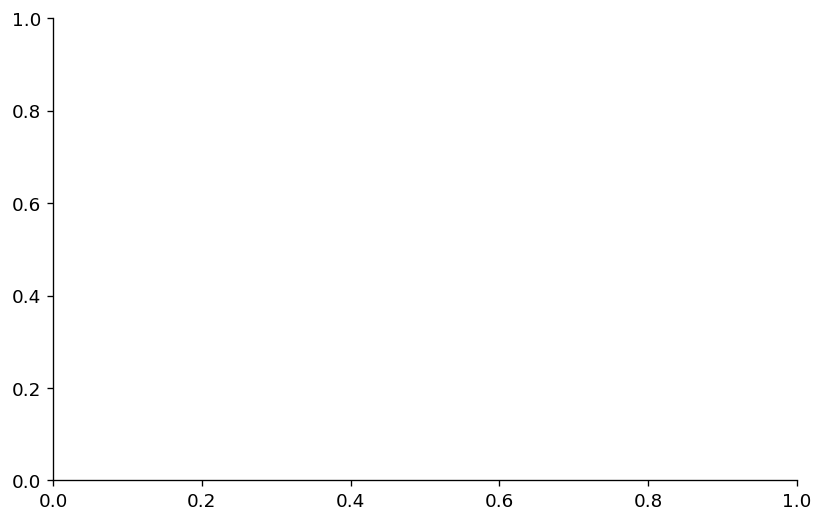

In [27]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

for i, hist_seed in enumerate(results_ionq['none']['history']):
    fv = [h['frac_valid_raw'] for h in hist_seed]
    ax.plot(range(1, len(fv) + 1), fv, 'o-', alpha=0.4, color='darkorange',
            label='IonQ (aria-1)' if i == 0 else None)

ax.axhline(0.2095, color='red', ls=':', label='random baseline')
ax.set_xlabel('Iteration')
ax.set_ylabel('frac_valid_raw')
ax.legend()
plt.show()